# A Reproducible and Leakage-Resistant Approach to Vehicle Price Prediction Using Cross-Validated Regression Models

### Problem Statement

The Australian used vehicle market exhibits substantial price variability driven by complex interactions among vehicle characteristics,
usage history, specification profiles, seller-side listing behaviour, and regional market conditions. Although large volumes of vehicle
listing data are publicly available through online marketplaces, the underlying mechanisms governing price formation remain highly
nonlinear, heterogeneous, and difficult to model using traditional valuation approaches based on fixed depreciation schedules or
manual appraisal heuristics.

Machine learning offers a powerful alternative for modelling high-dimensional structured marketplace data. However, many existing
vehicle price prediction studies suffer from methodological weaknesses, including insufficient leakage control, limited reproducibility,
weak validation design, and narrow model comparison. In addition, relatively little emphasis is placed on generalisation stability,
heteroscedastic error behaviour, computational trade-offs, and the structural interpretation of key valuation drivers.

Accordingly, there is a need for a methodologically rigorous, reproducible, and leakage-safe machine learning framework capable of
modelling Australian used vehicle prices with strong predictive performance while also producing interpretable insights into the
factors driving market valuation. This study addresses that need through a controlled comparative evaluation of five regression
paradigms under a unified experimental framework, enabling robust performance assessment, defensible methodological comparison,
and economically meaningful interpretation.

### Research Aim

This research aims to design and implement a rigorous, fully reproducible, and leakage-resistant machine learning framework for
predicting Australian used vehicle prices, enabling a controlled comparative evaluation of diverse regression paradigms while
identifying the structural and market-related determinants of price variation.

### Research Objectives

- To construct a robust preprocessing and feature engineering pipeline capable of transforming imperfect semi-structured vehicle
  listing data into a machine-learning-ready analytical dataset.
- To implement and compare five regression paradigms-Linear Regression, Random Forest, XGBoost, Support Vector Regression,
  and Artificial Neural Networks-within a consistent experimental framework.
- To enforce strict train-test separation and cross-validated training procedures in order to prevent data leakage and ensure
  unbiased evaluation.
- To assess model generalisation stability by comparing cross-validation behaviour against locked hold-out test-set performance.
- To analyse prediction error behaviour across price ranges and vehicle categories in order to detect heteroscedasticity,
  systematic underprediction, or model bias.
- To quantify the influence of key attributes using model-agnostic feature importance techniques and derive interpretable market insights.
- To evaluate computational efficiency, scalability, and practical deployment considerations across modelling paradigms.
- To generate robust, evidence-based findings that can support automated valuation systems and data-driven pricing strategies
  in the Australian vehicle market.

### Data Collection

The dataset used in this study was obtained from a publicly available Kaggle repository containing Australian vehicle listing data
aggregated from online automotive marketplaces. The dataset includes attributes such as price, year, mileage, fuel type,
transmission, body configuration, seller type, and geographic location.

Because the dataset reflects real marketplace conditions, it contains heterogeneous categories, semi-structured fields, missing values,
and potential inconsistencies that are characteristic of operational pricing data. These properties make it appropriate for evaluating
the robustness of different regression approaches under realistic data conditions.

No direct interaction with individuals was undertaken. The dataset contains no personally identifiable information (PII), and all analysis
was performed at listing level in a secure local computing environment for academic research purposes only.


### Dataset Source

Dataset Title: Australian Vehicle Prices
Data Repository: Kaggle
Dataset Author: Nidula Elgiriyewithana
Access Link:
https://www.kaggle.com/datasets/nelgiriyewithana/australian-vehicle-prices

Dataset Description:

The dataset comprises a large-scale collection of Australian used vehicle listings, integrating numerical pricing data with high-cardinality categorical and specification attributes. It supports rigorous machine learning modelling, feature engineering, and comparative evaluation of diverse predictive paradigms within a real-world marketplace context.

### Ethical, GDPR, and University of Hertfordshire Compliance Table

| **Aspect**                              | **Description**                                                                        | **Status**   |
| --------------------------------------- | -------------------------------------------------------------------------------------- | ------------ |
| Data Source                             | Publicly available Kaggle dataset derived from online vehicle marketplace listings     | Compliant    |
| Nature of Data                          | Secondary structured listing-level marketplace data                                    | Compliant    |
| Personal Identifiable Information (PII) | No names, contact details, or identifiable personal data included                      | Compliant    |
| Anonymisation                           | Dataset contains no identifiable individuals; analysis conducted at listing level      | Compliant    |
| GDPR Lawful Basis                       | Academic research using publicly available, anonymised secondary data                  | Compliant    |
| Participant Consent                     | Not required (secondary, anonymised public dataset)                                    | Compliant    |
| Sensitive Personal Data                 | No sensitive attributes (health, race, religion, political views) analysed or inferred | Compliant    |
| Data Minimisation                       | Only variables relevant to predictive modelling objectives were utilised               | Compliant    |
| Data Usage Purpose                      | Data used exclusively for academic research and dissertation reporting                 | Compliant    |
| Data Storage                            | Stored securely on a password-protected personal device                                | Compliant    |
| Data Sharing                            | Data not redistributed beyond academic submission                                      | Compliant    |
| Risk to Individuals                     | No interaction with individuals; aggregate listing-level analysis only                 | Minimal Risk |
| Re-identification Risk                  | No attempt made to identify, profile, or infer information about individuals           | Negligible   |
| University of Hertfordshire Ethics      | Meets low-risk exemption criteria for secondary data research                          | Compliant    |
| Ethical Approval Requirement            | Formal ethical approval not required (secondary anonymised data)                       | Exempt       |


In [1]:
# ============================================================
# Cell 1 — Global imports, reproducibility, and notebook utilities
# ============================================================
# Purpose:
# Set up the project environment for a clean, reproducible, and
# submission-ready workflow. This cell:
# 1) imports required libraries,
# 2) fixes random seeds,
# 3) configures notebook display/plotting defaults, and
# 4) defines shared helper utilities used later in the notebook.

import json
import os
import platform
import random
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# -----------------------------
# Optional visualisation library
# -----------------------------
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
    SEABORN_OK = True
except Exception:
    SEABORN_OK = False

# -----------------------------
# Scikit-learn / modelling tools
# -----------------------------
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# -----------------------------
# Optional gradient boosting
# -----------------------------
try:
    from xgboost import XGBRegressor
    XGB_OK = True
except Exception:
    XGB_OK = False

# ============================================================
# Reproducibility and runtime configuration
# ============================================================
RANDOM_STATE = 42
CV_FOLDS = 5
TEST_SIZE = 0.20
CURRENT_YEAR = 2026
N_JOBS = -1  # use all available CPU cores where supported

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Safer warning handling:
# keep important warnings visible while suppressing noisy user warnings only
warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# Notebook display configuration
# ============================================================
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
})

SAVE_FIGS = True

# ============================================================
# Colour palette
# ============================================================
COLORS = {
    "primary": "#1f77b4",
    "secondary": "#ff7f0e",
    "accent": "#2ca02c",
    "highlight": "#d62728",
    "purple": "#9467bd",
    "teal": "#17a2b8",
    "neutral": "#6c757d",
}

# ============================================================
# Shared helper functions
# ============================================================
def style_table(df: pd.DataFrame, gradient_subset=None):
    """
    Return a lightly formatted pandas Styler for report-friendly tables.
    """
    styled = (
        df.style
        .set_properties(**{"font-size": "11pt", "text-align": "left"})
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("font-size", "11pt"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                ],
            }
        ])
    )
    if gradient_subset is not None:
        styled = styled.background_gradient(subset=gradient_subset, cmap="YlOrRd")
    return styled


def save_figure(fig: plt.Figure, filename: str) -> Path:
    """
    Save a matplotlib figure to the figures directory and return the saved path.
    """
    out_path = FIG_DIR / filename
    if SAVE_FIGS:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"[Saved] {out_path}")
    return out_path


def show_and_save(fig: plt.Figure, filename: str | None = None) -> None:
    """
    Apply tight layout, optionally save the figure, and display it.
    """
    fig.tight_layout()
    if filename is not None:
        save_figure(fig, filename)
    plt.show()


def format_axis(ax, rotate_xticks: int = 0):
    """
    Apply consistent axis formatting.
    """
    ax.tick_params(axis="both", labelsize=11)
    if rotate_xticks:
        for label in ax.get_xticklabels():
            label.set_rotation(rotate_xticks)
            label.set_horizontalalignment("right")
    return ax


def rmse(y_true, y_pred) -> float:
    """
    Compute root mean squared error.
    """
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred) -> dict:
    """
    Return core regression metrics in dictionary form.
    """
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }


# ============================================================
# Environment snapshot
# ============================================================
ENV_INFO = {
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "random_state": RANDOM_STATE,
    "cv_folds": CV_FOLDS,
    "test_size": TEST_SIZE,
    "n_jobs": N_JOBS,
    "xgboost_available": XGB_OK,
}
print(json.dumps(ENV_INFO, indent=2))

{
  "python_version": "3.13.5",
  "platform": "Windows-11-10.0.26200-SP0",
  "random_state": 42,
  "cv_folds": 5,
  "test_size": 0.2,
  "n_jobs": -1,
  "xgboost_available": true
}


In [2]:
# ============================================================
# Cell 2 — Data loading and structural validation
# ============================================================
# Purpose:
# Locate the dataset robustly, load it safely with encoding fallback,
# standardise column names, and validate the basic dataset structure
# before any cleaning begins.

DATA_FILENAME = "Australian Vehicle Prices.csv"

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
]

DATA_PATH = None
PROJECT_ROOT = None

for root in candidate_roots:
    possible_path = root / "data" / DATA_FILENAME
    if possible_path.exists():
        PROJECT_ROOT = root
        DATA_DIR = PROJECT_ROOT / "data"
        FIG_DIR = PROJECT_ROOT / "figures"
        OUTPUT_DIR = PROJECT_ROOT / "outputs"
        DATA_PATH = possible_path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Dataset not found. Expected path like: project_root/data/{DATA_FILENAME}"
    )

# -----------------------------
# Validate expected project folders
# -----------------------------
required_folders = [DATA_DIR, FIG_DIR, OUTPUT_DIR]
missing_folders = [folder for folder in required_folders if not folder.exists()]
if missing_folders:
    missing_str = ", ".join(str(folder) for folder in missing_folders)
    raise FileNotFoundError(f"Expected project folder(s) not found: {missing_str}")

# -----------------------------
# Safe file loading with fallback
# -----------------------------
encodings_to_try = ["utf-8", "latin1", "cp1252"]
last_error = None

for enc in encodings_to_try:
    try:
        df = pd.read_csv(DATA_PATH, encoding=enc)
        file_encoding_used = enc
        break
    except UnicodeDecodeError as exc:
        last_error = exc
else:
    raise UnicodeDecodeError(
        getattr(last_error, "encoding", "unknown"),
        getattr(last_error, "object", b""),
        getattr(last_error, "start", 0),
        getattr(last_error, "end", 1),
        f"Unable to decode file using encodings: {encodings_to_try}"
    )

# -----------------------------
# Standardise column names
# -----------------------------
original_columns = df.columns.tolist()
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
)

# Preserve an untouched raw copy for audit/reference
df_raw = df.copy(deep=True)

# -----------------------------
# Basic structural checks
# -----------------------------
if df.empty:
    raise ValueError("Loaded dataset is empty.")

if len(df.columns) != len(set(df.columns)):
    duplicated_cols = pd.Series(df.columns)[pd.Series(df.columns).duplicated()].tolist()
    raise ValueError(f"Duplicate column names found after standardisation: {duplicated_cols}")

# Pre-compute frequently used summary values once
n_rows, n_cols = df.shape
total_cells = n_rows * n_cols
total_missing = int(df.isna().sum().sum())
missing_pct = round((total_missing / total_cells) * 100, 2) if total_cells > 0 else 0.0
duplicate_rows = int(df.duplicated().sum())

# -----------------------------
# Initial structural summary
# -----------------------------
initial_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing cells",
        "Missing (%)",
        "Duplicate rows",
        "Encoding used",
        "Data path",
    ],
    "Value": [
        n_rows,
        n_cols,
        total_missing,
        missing_pct,
        duplicate_rows,
        file_encoding_used,
        str(DATA_PATH),
    ],
})

env_summary = pd.DataFrame({
    "Setting": [
        "Python version",
        "Platform",
        "Project root",
        "Data directory",
        "Figures directory",
        "Outputs directory",
        "Seaborn available",
        "XGBoost available",
        "Random state",
        "CV folds",
        "Test size",
        "CPU parallel jobs",
    ],
    "Value": [
        platform.python_version(),
        f"{platform.system()} {platform.release()}",
        str(PROJECT_ROOT),
        str(DATA_DIR),
        str(FIG_DIR),
        str(OUTPUT_DIR),
        SEABORN_OK,
        XGB_OK,
        RANDOM_STATE,
        CV_FOLDS,
        TEST_SIZE,
        N_JOBS,
    ],
})

print("Dataset loaded successfully.")
display(env_summary)
display(style_table(initial_summary))
display(df.head())
display(df.dtypes.to_frame(name="dtype"))

Dataset loaded successfully.


,Setting,Value
0,Python version,3.13.5
1,Platform,Windows 11
2,Project root,c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project
3,Data directory,c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\data
4,Figures directory,c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures
5,Outputs directory,c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\outputs
6,Seaborn available,True
7,XGBoost available,True
8,Random state,42
9,CV folds,5


,Metric,Value
0,Rows,16734
1,Columns,19
2,Missing cells,4085
3,Missing (%),1.280000
4,Duplicate rows,0
5,Encoding used,utf-8
6,Data path,c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\data\Australian Vehicle Prices.csv


,Brand,Year,Model,Car/Suv,Title,UsedOrNew,Transmission,Engine,DriveType,FuelType,FuelConsumption,Kilometres,ColourExtInt,Location,CylindersinEngine,BodyType,Doors,Seats,Price
0,Ssangyong,2022.0,Rexton,Sutherland Isuzu Ute,2022 Ssangyong Rexton Ultimate (awd),DEMO,Automatic,"4 cyl, 2.2 L",AWD,Diesel,8.7 L / 100 km,5595,White / Black,"Caringbah, NSW",4 cyl,SUV,4 Doors,7 Seats,51990
1,MG,2022.0,MG3,Hatchback,2022 MG MG3 Auto Excite (with Navigation),USED,Automatic,"4 cyl, 1.5 L",Front,Premium,6.7 L / 100 km,16,Black / Black,"Brookvale, NSW",4 cyl,Hatchback,5 Doors,5 Seats,19990
2,BMW,2022.0,430I,Coupe,2022 BMW 430I M Sport,USED,Automatic,"4 cyl, 2 L",Rear,Premium,6.6 L / 100 km,8472,Grey / White,"Sylvania, NSW",4 cyl,Coupe,2 Doors,4 Seats,108988
3,Mercedes-Benz,2011.0,E500,Coupe,2011 Mercedes-Benz E500 Elegance,USED,Automatic,"8 cyl, 5.5 L",Rear,Premium,11 L / 100 km,136517,White / Brown,"Mount Druitt, NSW",8 cyl,Coupe,2 Doors,4 Seats,32990
4,Renault,2022.0,Arkana,SUV,2022 Renault Arkana Intens,USED,Automatic,"4 cyl, 1.3 L",Front,Unleaded,6 L / 100 km,1035,Grey / Black,"Castle Hill, NSW",4 cyl,SUV,4 Doors,5 Seats,34990


,dtype
Brand,object
Year,float64
Model,object
Car/Suv,object
Title,object
UsedOrNew,object
Transmission,object
Engine,object
DriveType,object
FuelType,object


In [3]:
# ============================================================
# Cell 3 — Dataset overview and data dictionary
# ============================================================
# Purpose:
# Summarise the dataset at both table and column level to document
# structure, feature types, missingness, cardinality, and example values.
# This creates a clear audit trail for later cleaning decisions.

# Reuse summary values computed in Cell 2 where possible
dataset_overview = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Missing cells", "Missing (%)", "Duplicate rows"],
    "Value": [
        n_rows,
        n_cols,
        total_missing,
        missing_pct,
        duplicate_rows,
    ],
})

non_null_counts = df.notna().sum()
missing_counts = df.isna().sum()
missing_percents = df.isna().mean().mul(100).round(2)
unique_counts = df.nunique(dropna=True)

example_values = []
for col in df.columns:
    non_null_series = df[col].dropna()
    example_values.append(non_null_series.iloc[0] if not non_null_series.empty else None)

data_dict = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": non_null_counts.values,
    "missing_count": missing_counts.values,
    "missing_%": missing_percents.values,
    "unique_count": unique_counts.values,
    "example_value": example_values,
}).sort_values(
    by=["missing_%", "unique_count"],
    ascending=[False, False],
).reset_index(drop=True)

metadata_json = {
    "rows": n_rows,
    "columns": n_cols,
    "duplicate_rows": duplicate_rows,
    "missing_percent_by_column": missing_percents.to_dict(),
}

display(style_table(dataset_overview))
display(
    style_table(data_dict, gradient_subset=["missing_%"])
    .format({"missing_%": "{:.2f}%"})
)

print("Dataset metadata summary:")
print(json.dumps(metadata_json, indent=2))

,Metric,Value
0,Rows,16734.000000
1,Columns,19.000000
2,Missing cells,4085.000000
3,Missing (%),1.280000
4,Duplicate rows,0.000000


,feature,dtype,non_null_count,missing_count,missing_%,unique_count,example_value
0,Seats,object,15029,1705,10.19%,13,7 Seats
1,Doors,object,15130,1604,9.59%,13,4 Doors
2,Location,object,16284,450,2.69%,618,"Caringbah, NSW"
3,BodyType,object,16452,282,1.69%,10,SUV
4,Car/Suv,object,16706,28,0.17%,618,Sutherland Isuzu Ute
5,Price,object,16731,3,0.02%,3794,51990
6,Kilometres,object,16733,1,0.01%,14262,5595
7,Title,object,16733,1,0.01%,8804,2022 Ssangyong Rexton Ultimate (awd)
8,ColourExtInt,object,16733,1,0.01%,834,White / Black
9,Model,object,16733,1,0.01%,781,Rexton


Dataset metadata summary:
{
  "rows": 16734,
  "columns": 19,
  "duplicate_rows": 0,
  "missing_percent_by_column": {
    "Brand": 0.01,
    "Year": 0.01,
    "Model": 0.01,
    "Car/Suv": 0.17,
    "Title": 0.01,
    "UsedOrNew": 0.01,
    "Transmission": 0.01,
    "Engine": 0.01,
    "DriveType": 0.01,
    "FuelType": 0.01,
    "FuelConsumption": 0.01,
    "Kilometres": 0.01,
    "ColourExtInt": 0.01,
    "Location": 2.69,
    "CylindersinEngine": 0.01,
    "BodyType": 1.69,
    "Doors": 9.59,
    "Seats": 10.19,
    "Price": 0.02
  }
}


In [4]:
# ============================================================
# Cell 4 — Data quality audit
# ============================================================
# Purpose:
# Audit duplicates, missing-value proxies, and feature types before
# detailed cleaning. This makes the cleaning process transparent,
# defensible, and easier to justify in the report.

shape_before = df.shape
duplicate_count = int(df.duplicated().sum())

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

shape_after = df.shape
rows_removed_duplicates = int(shape_before[0] - shape_after[0])

# -----------------------------
# Dtype and missingness audit
# -----------------------------
object_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

missing_percents = df.isna().mean().mul(100).round(2)
unique_counts = df.nunique(dropna=True)

dtype_table = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_%": missing_percents.values,
    "unique_count": unique_counts.values,
}).sort_values(
    by=["dtype", "missing_%"],
    ascending=[True, False]
).reset_index(drop=True)

# -----------------------------
# Placeholder-like value audit
# -----------------------------
placeholder_tokens = {
    "", "-", "--", "- / -", "na", "n/a", "none", "null", "unknown", "?"
}

placeholder_records = []
for col in object_cols:
    series = df[col].fillna("").astype(str).str.strip().str.lower()
    count = int(series.isin(placeholder_tokens).sum())
    if count > 0:
        placeholder_records.append({
            "feature": col,
            "placeholder_like_count": count,
            "placeholder_like_%": round((count / len(df)) * 100, 2)
        })

if placeholder_records:
    placeholder_df = pd.DataFrame(placeholder_records).sort_values(
        by="placeholder_like_count",
        ascending=False
    ).reset_index(drop=True)
else:
    placeholder_df = pd.DataFrame(
        columns=["feature", "placeholder_like_count", "placeholder_like_%"]
    )

features_with_missing = int((missing_percents > 0).sum())

audit_summary = pd.DataFrame({
    "Metric": [
        "Rows before duplicate removal",
        "Rows after duplicate removal",
        "Duplicate rows removed",
        "Object features",
        "Numeric features",
        "Features with missing values",
        "Features with placeholder-like values",
    ],
    "Value": [
        int(shape_before[0]),
        int(shape_after[0]),
        rows_removed_duplicates,
        len(object_cols),
        len(numeric_cols),
        features_with_missing,
        len(placeholder_df),
    ]
})

print("Data quality audit completed.")
display(style_table(audit_summary))
display(
    style_table(dtype_table, gradient_subset=["missing_%"])
    .format({"missing_%": "{:.2f}%"})
)

if not placeholder_df.empty:
    display(
        style_table(placeholder_df, gradient_subset=["placeholder_like_%"])
        .format({"placeholder_like_%": "{:.2f}%"})
    )
else:
    print("No placeholder-like values detected in object columns.")

Data quality audit completed.


,Metric,Value
0,Rows before duplicate removal,16734
1,Rows after duplicate removal,16734
2,Duplicate rows removed,0
3,Object features,18
4,Numeric features,1
5,Features with missing values,19
6,Features with placeholder-like values,18


,feature,dtype,missing_%,unique_count
0,Year,float64,0.01%,45
1,Seats,object,10.19%,13
2,Doors,object,9.59%,13
3,Location,object,2.69%,618
4,BodyType,object,1.69%,10
5,Car/Suv,object,0.17%,618
6,Price,object,0.02%,3794
7,Brand,object,0.01%,76
8,Model,object,0.01%,781
9,Title,object,0.01%,8804


,feature,placeholder_like_count,placeholder_like_%
0,Seats,1705,10.19%
1,FuelConsumption,1698,10.15%
2,CylindersinEngine,1675,10.01%
3,Engine,1675,10.01%
4,Doors,1604,9.59%
5,FuelType,638,3.81%
6,Kilometres,592,3.54%
7,Location,450,2.69%
8,ColourExtInt,360,2.15%
9,BodyType,282,1.69%


In [5]:
# ============================================================
# Cell 5 — Target cleaning and transformation
# ============================================================
# Purpose:
# Clean the target variable, remove non-trainable price entries,
# and prepare both raw and log-transformed targets so the response
# variable is valid and modelling-ready.

TARGET_COL = "Price"

if TARGET_COL not in df.columns:
    raise KeyError(
        f"Target column '{TARGET_COL}' not found. Available columns: {df.columns.tolist()}"
    )

rows_before_target_cleaning = len(df)

# Preserve original target values for audit
target_before_cleaning = df[TARGET_COL].copy()

# -----------------------------
# Standardise and detect invalid entries
# -----------------------------
target_series = df[TARGET_COL].astype(str).str.strip()

target_missing_tokens = {"", "poa", "n/a", "na", "null", "none", "-", "--", "unknown"}
target_series_lower = target_series.str.lower()

is_placeholder_target = target_series_lower.isin(target_missing_tokens)
poa_count = int(target_series_lower.eq("poa").sum())
placeholder_count = int(is_placeholder_target.sum())

# Replace placeholder-like values with missing
target_series = target_series.mask(is_placeholder_target, np.nan)

# Remove non-numeric symbols but preserve digits, decimal points, and minus signs
target_series = target_series.str.replace(r"[^\d.\-]", "", regex=True)
target_series = pd.to_numeric(target_series, errors="coerce")

df[TARGET_COL] = target_series

# -----------------------------
# Drop invalid target rows
# -----------------------------
rows_before_dropna = len(df)
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
rows_dropped_missing = rows_before_dropna - len(df)

rows_before_positive_filter = len(df)
df = df[df[TARGET_COL] > 0].reset_index(drop=True)
rows_dropped_non_positive = rows_before_positive_filter - len(df)

# Final target objects
y_raw = df[TARGET_COL].copy()
y_log = np.log1p(y_raw)

target_min = float(y_raw.min())
target_median = float(y_raw.median())
target_max = float(y_raw.max())

target_audit = pd.DataFrame({
    "Metric": [
        "Rows before target cleaning",
        "POA rows",
        "Placeholder-like target rows",
        "Rows dropped for missing target",
        "Rows dropped for non-positive target",
        "Rows remaining after target cleaning",
        "Minimum valid price",
        "Median valid price",
        "Maximum valid price",
    ],
    "Value": [
        rows_before_target_cleaning,
        poa_count,
        placeholder_count,
        rows_dropped_missing,
        rows_dropped_non_positive,
        len(df),
        target_min,
        target_median,
        target_max,
    ]
})

print("Target cleaning completed.")
display(style_table(target_audit))
display(y_raw.describe().to_frame(name="Price summary"))

Target cleaning completed.


,Metric,Value
0,Rows before target cleaning,16734.000000
1,POA rows,50.000000
2,Placeholder-like target rows,50.000000
3,Rows dropped for missing target,53.000000
4,Rows dropped for non-positive target,0.000000
5,Rows remaining after target cleaning,16681.000000
6,Minimum valid price,88.000000
7,Median valid price,29500.000000
8,Maximum valid price,1500000.000000


,Price summary
count,1.668100e+04
mean,3.730333e+04
std,3.717787e+04
min,8.800000e+01
25%,1.899900e+04
50%,2.950000e+04
75%,4.399000e+04
max,1.500000e+06


[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_01_target_distributions.png


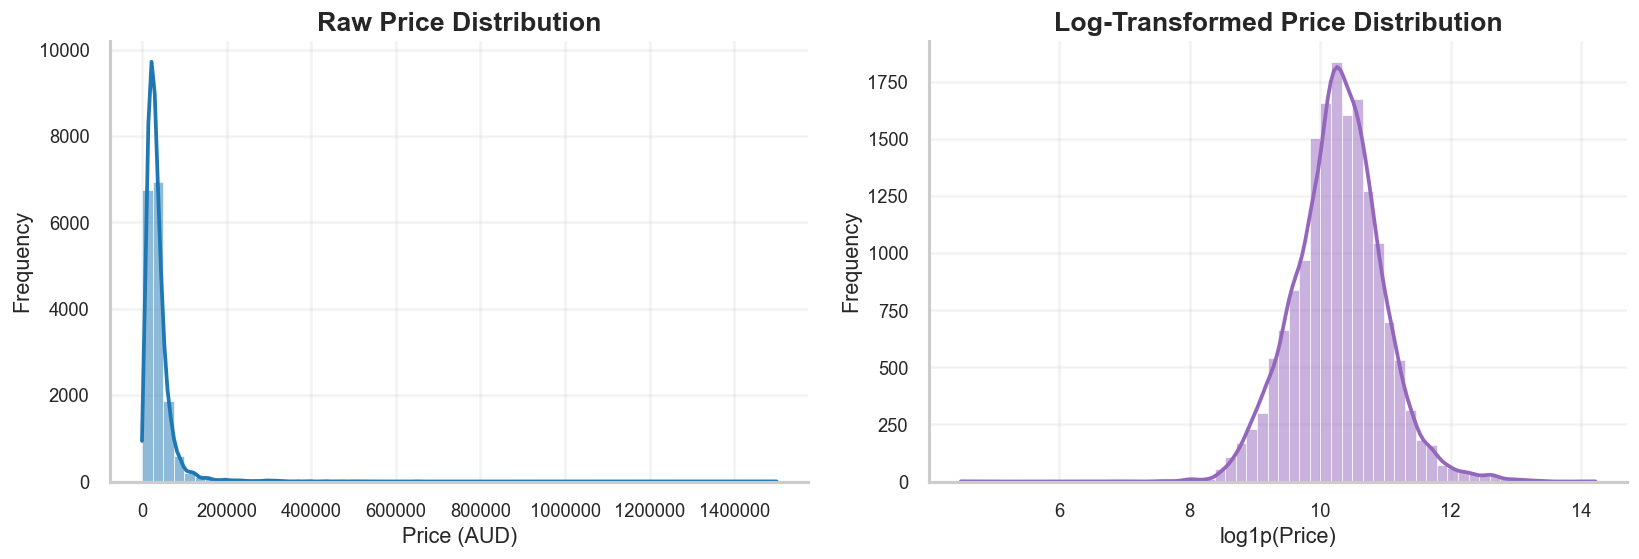

,Scale,Mean,Median,Std,Skewness,Kurtosis
0,Raw price,37303.334600,29500.000000,37177.867000,8.661600,190.412900
1,Log-transformed price,10.279500,10.292200,0.677800,0.116500,1.212700


,Metric,Value
0,Q1,18999.000000
1,Q3,43990.000000
2,IQR,24991.000000
3,Upper outlier bound,81476.500000
4,Outlier count,931.000000
5,Outlier (%),5.580000


In [6]:
# ============================================================
# Cell 6 — Target distribution and outlier evidence
# ============================================================
# Purpose:
# Visualise the raw and log-transformed target distributions and
# quantify the reduction in skewness. This provides empirical
# justification for modelling log1p(price) rather than raw price.

raw_mean = float(y_raw.mean())
raw_median = float(y_raw.median())
raw_std = float(y_raw.std())
raw_skew = float(y_raw.skew())
raw_kurt = float(y_raw.kurt())

log_mean = float(y_log.mean())
log_median = float(y_log.median())
log_std = float(y_log.std())
log_skew = float(y_log.skew())
log_kurt = float(y_log.kurt())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# Raw and log-transformed target distributions
# -----------------------------
if SEABORN_OK:
    sns.histplot(
        y_raw,
        bins=60,
        kde=True,
        ax=axes[0],
        color=COLORS["primary"],
        edgecolor="white",
        linewidth=0.4
    )
    sns.histplot(
        y_log,
        bins=60,
        kde=True,
        ax=axes[1],
        color=COLORS["purple"],
        edgecolor="white",
        linewidth=0.4
    )
else:
    axes[0].hist(
        y_raw,
        bins=60,
        color=COLORS["primary"],
        edgecolor="white",
        linewidth=0.4
    )
    axes[1].hist(
        y_log,
        bins=60,
        color=COLORS["purple"],
        edgecolor="white",
        linewidth=0.4
    )

axes[0].set_title("Raw Price Distribution")
axes[0].set_xlabel("Price (AUD)")
axes[0].set_ylabel("Frequency")
axes[0].ticklabel_format(style="plain", axis="x")

axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("log1p(Price)")
axes[1].set_ylabel("Frequency")

for ax in axes:
    format_axis(ax)

show_and_save(fig, "figure_01_target_distributions.png")

target_distribution_compare = pd.DataFrame({
    "Scale": ["Raw price", "Log-transformed price"],
    "Mean": [round(raw_mean, 4), round(log_mean, 4)],
    "Median": [round(raw_median, 4), round(log_median, 4)],
    "Std": [round(raw_std, 4), round(log_std, 4)],
    "Skewness": [round(raw_skew, 4), round(log_skew, 4)],
    "Kurtosis": [round(raw_kurt, 4), round(log_kurt, 4)],
})

q1, q3 = y_raw.quantile([0.25, 0.75])
iqr = q3 - q1
upper_outlier_bound = q3 + 1.5 * iqr
outlier_mask = y_raw > upper_outlier_bound
outlier_count = int(outlier_mask.sum())
outlier_pct = round((outlier_count / len(y_raw)) * 100, 2)

outlier_summary = pd.DataFrame({
    "Metric": ["Q1", "Q3", "IQR", "Upper outlier bound", "Outlier count", "Outlier (%)"],
    "Value": [
        float(q1),
        float(q3),
        float(iqr),
        float(upper_outlier_bound),
        outlier_count,
        outlier_pct,
    ]
})

display(style_table(target_distribution_compare, gradient_subset=["Skewness", "Kurtosis"]))
display(style_table(outlier_summary))

,feature,missing_%
0,Seats,10.12%
1,Doors,9.51%
2,Location,2.69%
3,BodyType,1.67%
4,Car/Suv,0.16%
5,Brand,0.00%
6,Year,0.00%
7,Model,0.00%
8,Title,0.00%
9,UsedOrNew,0.00%


[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_02_missingness_profile.png


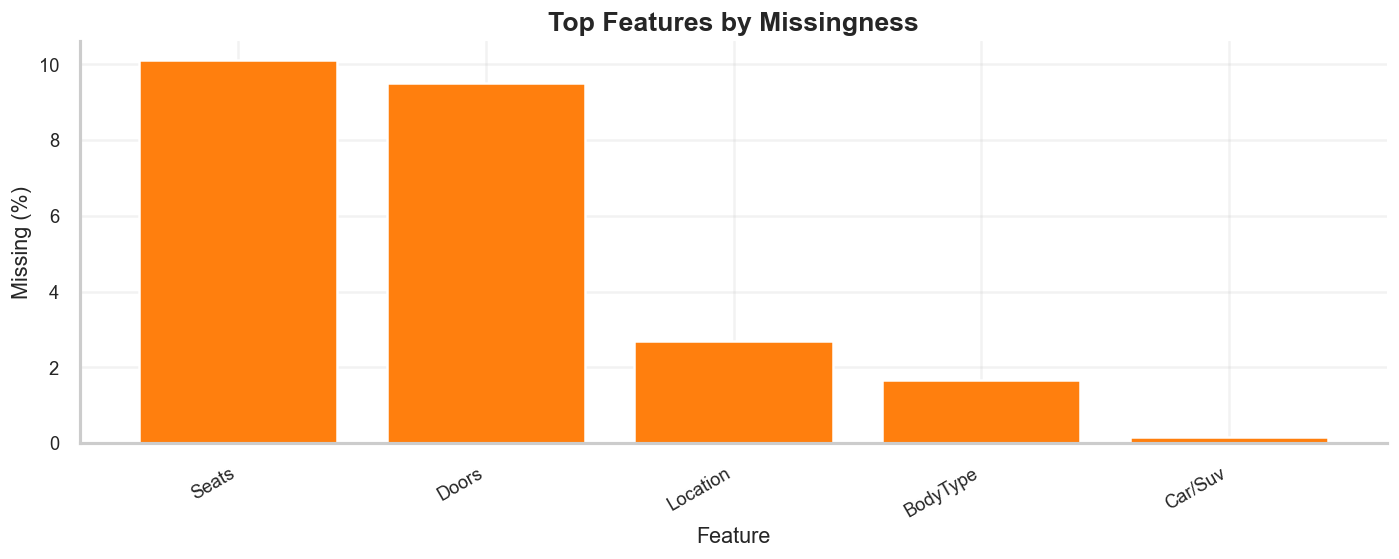

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_03_core_numeric_distributions.png


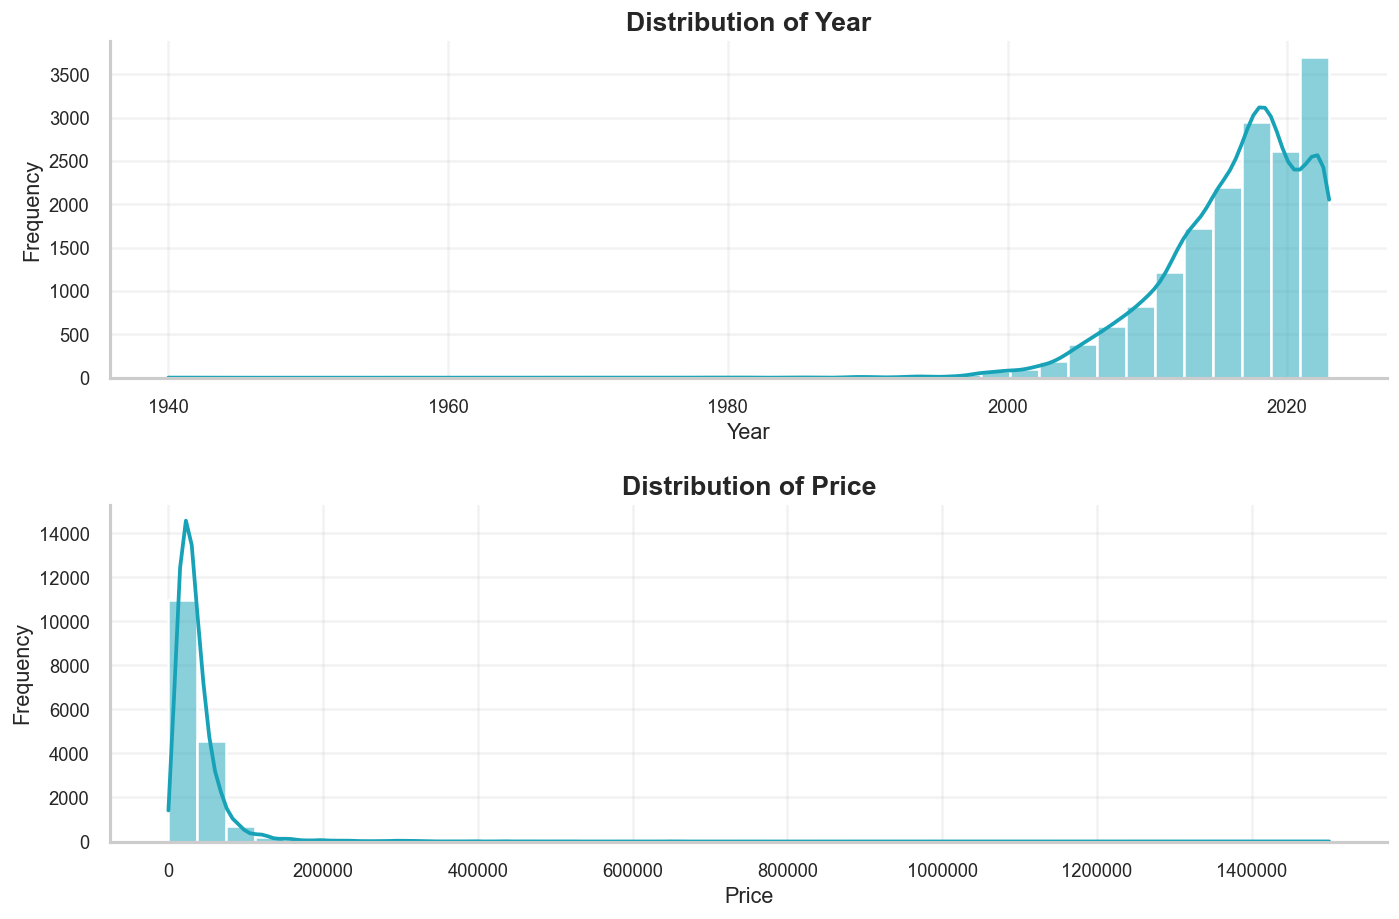

In [7]:
# ============================================================
# Cell 7 — Missingness profile and numeric feature distributions
# ============================================================
# Purpose:
# Assess feature-level missingness and inspect the distribution of
# key numeric variables. This supports cleaning choices,
# transformation decisions, and outlier awareness.

missing_profile = (
    df.isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_%")
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(
    style_table(missing_profile.head(15), gradient_subset=["missing_%"])
    .format({"missing_%": "{:.2f}%"})
)

# -----------------------------
# Missingness bar chart
# -----------------------------
max_missing = float(missing_profile["missing_%"].max()) if not missing_profile.empty else 0.0

if max_missing > 0:
    top_missing = missing_profile[missing_profile["missing_%"] > 0].head(12).copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(top_missing["feature"], top_missing["missing_%"], color=COLORS["secondary"])
    ax.set_title("Top Features by Missingness")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Missing (%)")
    format_axis(ax, rotate_xticks=30)
    show_and_save(fig, "figure_02_missingness_profile.png")
else:
    print("No missing values detected in the dataset.")

# -----------------------------
# Numeric feature distributions
# -----------------------------
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

numeric_candidates = [col for col in ["Year", TARGET_COL] if col in df.columns]

if numeric_candidates:
    nrows = len(numeric_candidates)
    fig, axes = plt.subplots(nrows, 1, figsize=(12, 4 * nrows))
    if nrows == 1:
        axes = [axes]

    for ax, col in zip(axes, numeric_candidates):
        series = df[col].dropna()

        if SEABORN_OK:
            sns.histplot(
                series,
                bins=40,
                kde=True,
                ax=ax,
                color=COLORS["teal"]
            )
        else:
            ax.hist(series, bins=40, color=COLORS["teal"], edgecolor="white", linewidth=0.4)

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

        if col == TARGET_COL:
            ax.ticklabel_format(style="plain", axis="x")

        format_axis(ax)

    show_and_save(fig, "figure_03_core_numeric_distributions.png")
else:
    print("No numeric candidates available for distribution plotting.")

,feature,unique_count,top_category,top_category_count
0,Model,781,Hilux,430
1,Brand,76,Toyota,2782
2,BodyType,10,SUV,6886
3,FuelType,9,Unleaded,6962
4,DriveType,5,Front,6957
5,UsedOrNew,3,USED,14984
6,Transmission,3,Automatic,14488


[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_cat_brand.png


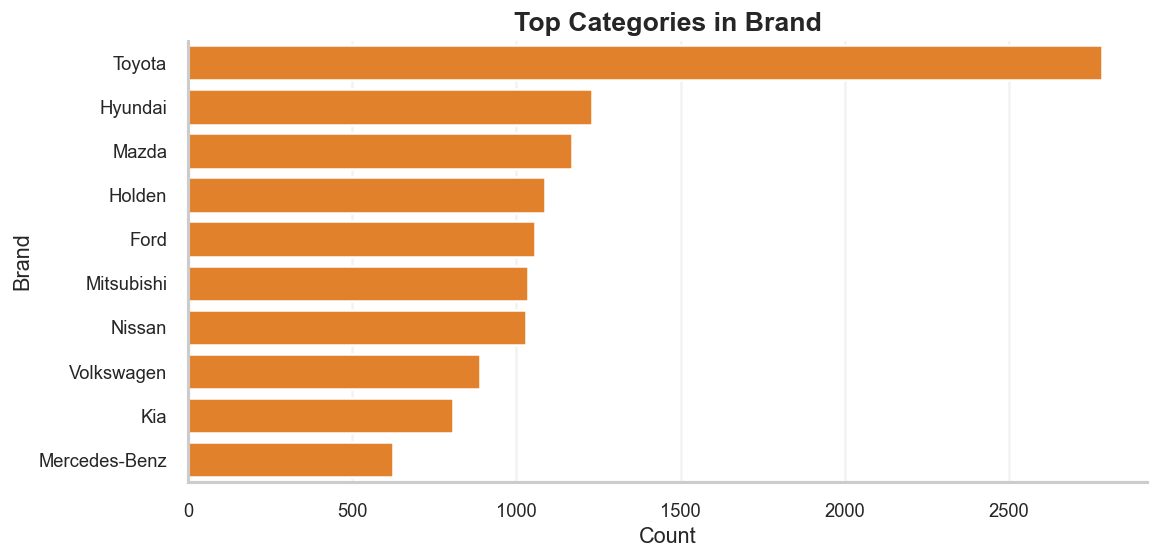

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_cat_model.png


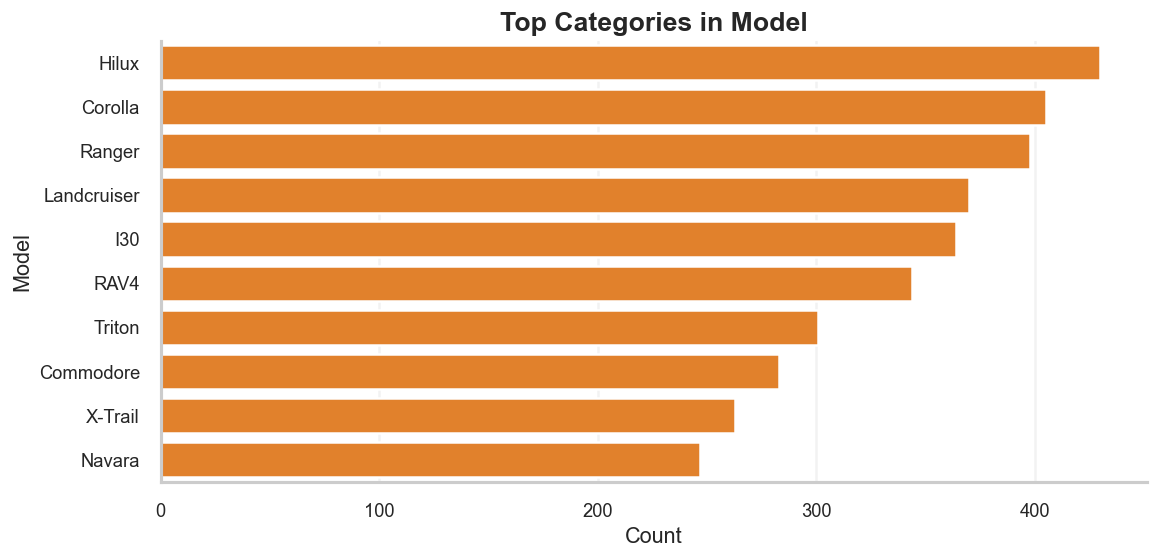

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_cat_usedornew.png


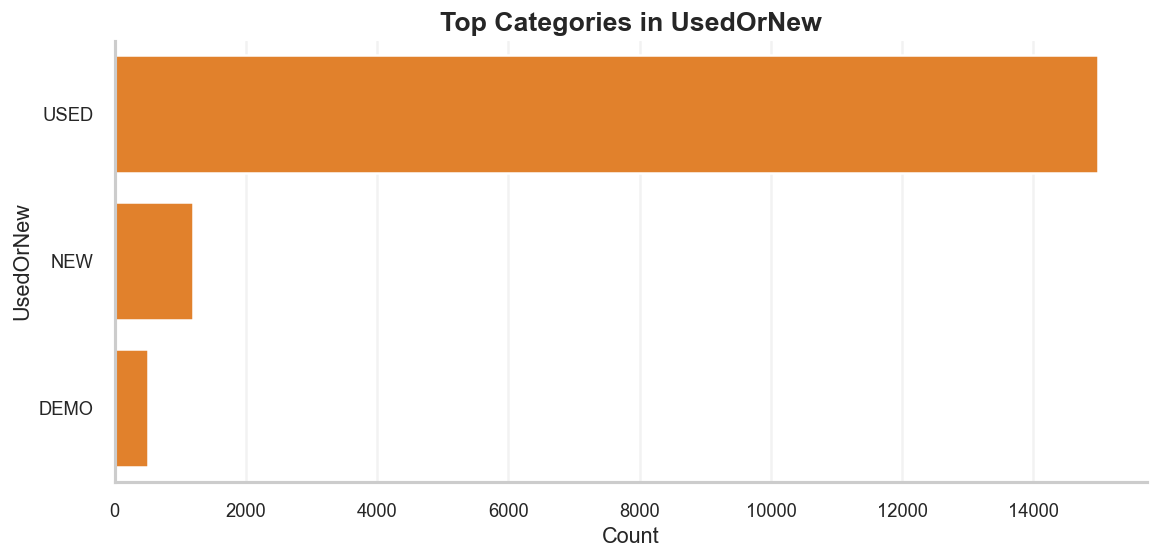

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_cat_transmission.png


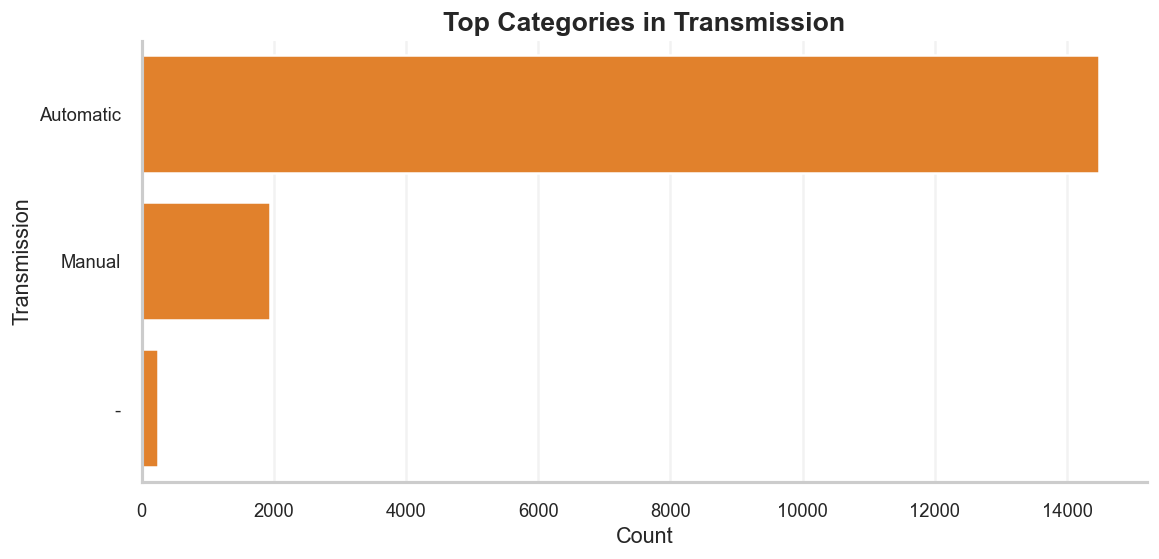

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_cat_fueltype.png


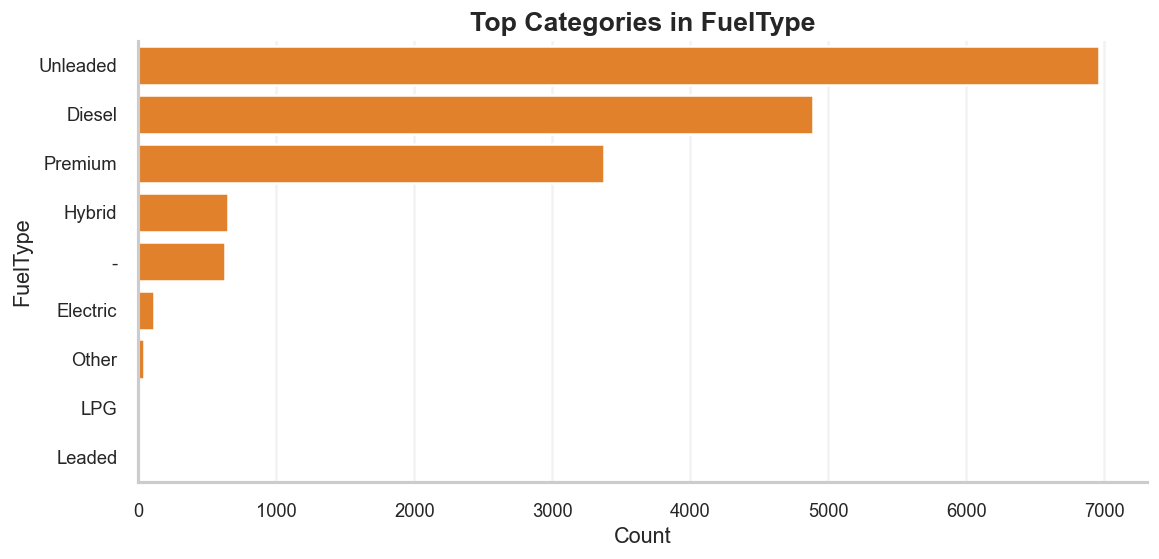

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_cat_bodytype.png


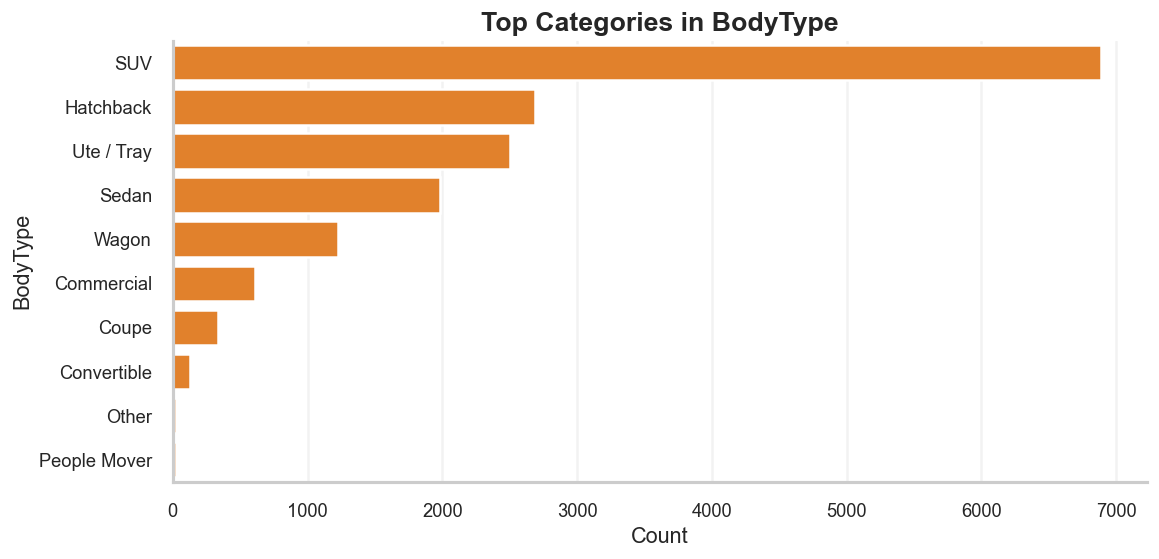

In [8]:
# ============================================================
# Cell 8 — Categorical exploratory analysis
# ============================================================
# Purpose:
# Inspect the dominant categories in important categorical variables
# to understand class imbalance, market composition, and potential
# encoding complexity before modelling.

categorical_candidates = [
    col for col in [
        "Brand", "Model", "UsedOrNew", "Transmission",
        "FuelType", "BodyType", "DriveType", "SellerType"
    ]
    if col in df.columns
]

cat_summary_records = []
for col in categorical_candidates:
    non_null = df[col].dropna()

    if non_null.empty:
        top_category = None
        top_category_count = 0
    else:
        value_counts = non_null.value_counts()
        top_category = value_counts.index[0]
        top_category_count = int(value_counts.iloc[0])

    cat_summary_records.append({
        "feature": col,
        "unique_count": int(df[col].nunique(dropna=True)),
        "top_category": top_category,
        "top_category_count": top_category_count,
    })

cat_summary_df = pd.DataFrame(cat_summary_records).sort_values(
    by="unique_count",
    ascending=False
).reset_index(drop=True)

display(style_table(cat_summary_df))

# -----------------------------
# Top-category bar charts
# -----------------------------
for col in categorical_candidates[:6]:
    top_vals = df[col].dropna().astype(str).value_counts().head(10)

    if top_vals.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    if SEABORN_OK:
        sns.barplot(
            x=top_vals.values,
            y=top_vals.index.astype(str),
            ax=ax,
            color=COLORS["secondary"]
        )
    else:
        ax.barh(top_vals.index.astype(str), top_vals.values, color=COLORS["secondary"])

    ax.set_title(f"Top Categories in {col}")
    ax.set_xlabel("Count")
    ax.set_ylabel(col)
    format_axis(ax)
    show_and_save(fig, f"figure_cat_{col.lower()}.png")

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_price_vs_year.png


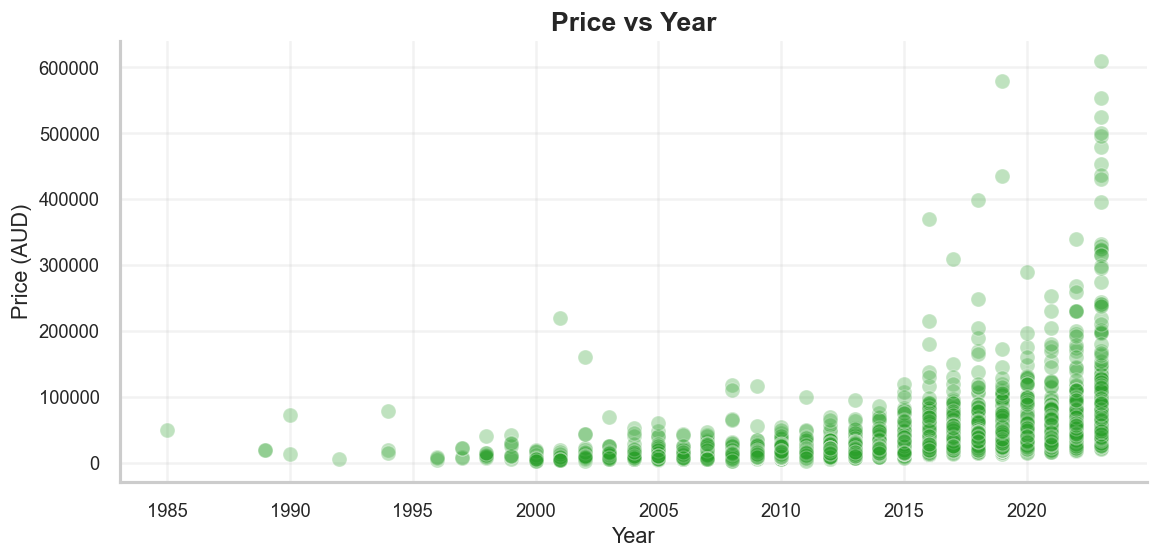

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_price_vs_kilometres_eda.png


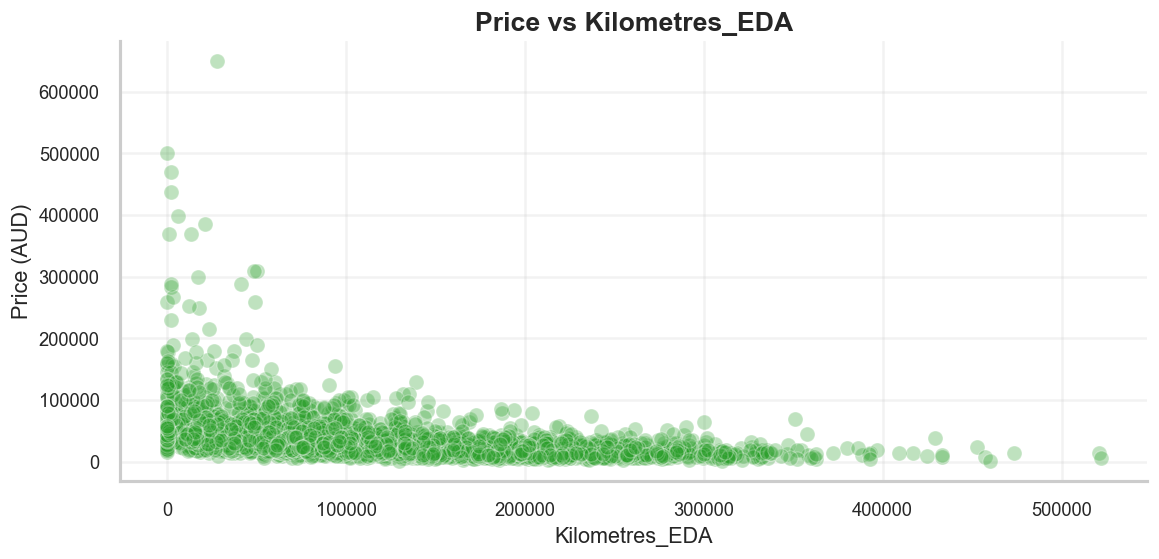

,FuelType,count,median,mean
0,Unleaded,6962,23493.500000,25615.692330
1,Diesel,4888,35055.000000,41898.349836
2,Premium,3372,35990.000000,48947.035587
3,Hybrid,650,45965.000000,57344.467692
4,-,632,31997.000000,39231.283228
5,Electric,115,59360.000000,86183.026087
6,Other,42,29974.500000,34670.285714
7,LPG,15,15990.000000,15420.133333
8,Leaded,5,69000.000000,81072.000000


[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_04_median_price_by_fueltype.png


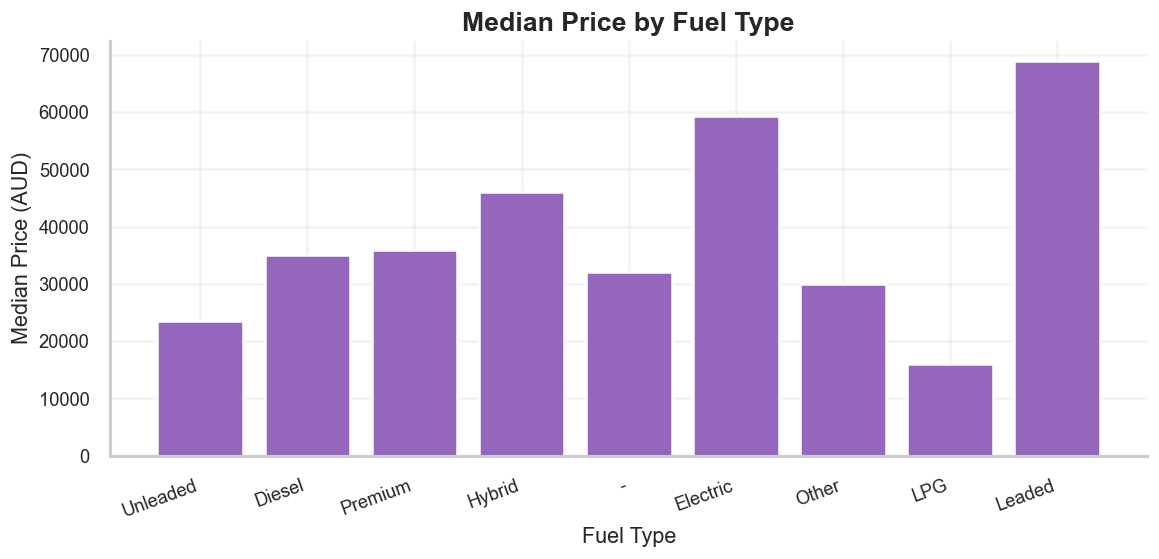

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_05_correlation_matrix.png


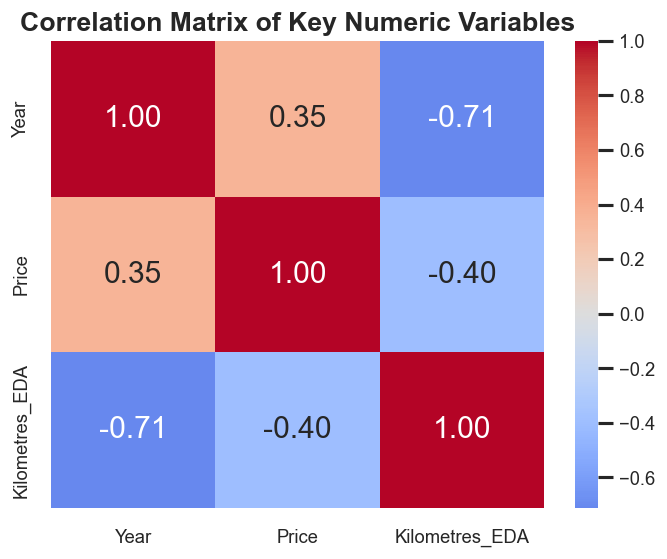

In [9]:
# ============================================================
# Cell 9 — Bivariate EDA and correlation analysis
# ============================================================
# Purpose:
# Examine relationships between price and key predictors, and
# evaluate the numeric correlation structure. This supports feature
# reasoning and gives evidence for later model choice.

# -----------------------------
# Parse a simple mileage signal for EDA only
# -----------------------------
if "Kilometres" in df.columns and "Kilometres_EDA" not in df.columns:
    kilometres_eda = (
        df["Kilometres"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.extract(r"(\d+)", expand=False)
    )
    df["Kilometres_EDA"] = pd.to_numeric(kilometres_eda, errors="coerce")

eda_pairs = [col for col in ["Year", "Kilometres_EDA"] if col in df.columns]

# -----------------------------
# Scatterplots against price
# -----------------------------
for col in eda_pairs:
    plot_df = df[[col, TARGET_COL]].dropna().copy()

    if len(plot_df) > 5000:
        plot_df = plot_df.sample(5000, random_state=RANDOM_STATE)

    fig, ax = plt.subplots(figsize=(10, 5))

    if SEABORN_OK:
        sns.scatterplot(
            data=plot_df,
            x=col,
            y=TARGET_COL,
            alpha=0.3,
            ax=ax,
            color=COLORS["accent"]
        )
    else:
        ax.scatter(
            plot_df[col],
            plot_df[TARGET_COL],
            alpha=0.3,
            color=COLORS["accent"]
        )

    ax.set_title(f"Price vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Price (AUD)")
    ax.ticklabel_format(style="plain", axis="y")
    format_axis(ax)
    show_and_save(fig, f"figure_price_vs_{col.lower()}.png")

# -----------------------------
# Price by fuel type
# -----------------------------
if "FuelType" in df.columns:
    fuel_price = (
        df.groupby("FuelType", dropna=False)[TARGET_COL]
        .agg(["count", "median", "mean"])
        .sort_values("count", ascending=False)
        .head(10)
        .reset_index()
    )

    display(style_table(fuel_price))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(fuel_price["FuelType"].astype(str), fuel_price["median"], color=COLORS["purple"])
    ax.set_title("Median Price by Fuel Type")
    ax.set_xlabel("Fuel Type")
    ax.set_ylabel("Median Price (AUD)")
    ax.ticklabel_format(style="plain", axis="y")
    format_axis(ax, rotate_xticks=20)
    show_and_save(fig, "figure_04_median_price_by_fueltype.png")

# -----------------------------
# Correlation matrix
# -----------------------------
corr_cols = [col for col in ["Year", TARGET_COL, "Kilometres_EDA"] if col in df.columns]
corr_df = df[corr_cols].copy()

if corr_df.shape[1] >= 2:
    corr = corr_df.corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(6, 5))
    if SEABORN_OK:
        sns.heatmap(
            corr,
            annot=True,
            cmap="coolwarm",
            center=0,
            fmt=".2f",
            ax=ax
        )
    else:
        cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
        fig.colorbar(cax)
        ax.set_xticks(range(len(corr.columns)))
        ax.set_yticks(range(len(corr.columns)))
        ax.set_xticklabels(corr.columns, rotation=30, ha="right")
        ax.set_yticklabels(corr.columns)

        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)

    ax.set_title("Correlation Matrix of Key Numeric Variables")
    show_and_save(fig, "figure_05_correlation_matrix.png")
else:
    print("Not enough numeric variables available for correlation analysis.")

In [10]:
# ============================================================
# Cell 10 — Strict train/test split
# ============================================================
# Purpose:
# Create one locked hold-out test set and preserve both raw and
# log-transformed targets. This ensures that all feature engineering,
# tuning, and model selection remain strictly confined to the
# training data.

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found in the dataset.")

X = df.drop(columns=[TARGET_COL]).copy()
y_raw_full = df[TARGET_COL].copy()

if (y_raw_full <= 0).any():
    raise ValueError(
        "Target contains non-positive values. Complete target cleaning before this step."
    )

y_log_full = np.log1p(y_raw_full)

# -----------------------------
# Optional stratification by price bands
# -----------------------------
stratify_labels = None
try:
    y_bins = pd.qcut(y_raw_full, q=10, duplicates="drop")
    if getattr(y_bins, "nunique", lambda: 0)() >= 2:
        stratify_labels = y_bins
except Exception:
    stratify_labels = None

X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X,
    y_raw_full,
    y_log_full,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_labels
)

split_summary = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "Percentage": [
        round((len(X_train) / len(X)) * 100, 2),
        round((len(X_test) / len(X)) * 100, 2)
    ],
    "Raw price mean": [
        round(float(y_train_raw.mean()), 2),
        round(float(y_test_raw.mean()), 2)
    ],
    "Raw price median": [
        round(float(y_train_raw.median()), 2),
        round(float(y_test_raw.median()), 2)
    ],
    "Raw price std": [
        round(float(y_train_raw.std()), 2),
        round(float(y_test_raw.std()), 2)
    ],
    "Log price mean": [
        round(float(y_train_log.mean()), 4),
        round(float(y_test_log.mean()), 4)
    ],
    "Log price std": [
        round(float(y_train_log.std()), 4),
        round(float(y_test_log.std()), 4)
    ]
})

print("Strict train/test split completed.")
display(style_table(split_summary))

Strict train/test split completed.


,Subset,Rows,Percentage,Raw price mean,Raw price median,Raw price std,Log price mean,Log price std
0,Train,13344,80.000000,37346.210000,29500.000000,37825.690000,10.280000,0.677600
1,Test,3337,20.000000,37131.880000,29500.000000,34470.730000,10.277200,0.678800


In [11]:
# ============================================================
# Cell 11 — Leakage-safe feature engineering transformer
# ============================================================
# Purpose:
# Define a deterministic custom transformer that parses semi-structured
# marketplace fields and creates derived predictors inside the modelling
# pipeline. This keeps feature engineering reproducible and leakage-safe
# during cross-validation and final model evaluation.

class VehicleFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, current_year=CURRENT_YEAR):
        self.current_year = current_year
        self.placeholder_tokens = {
            "", "-", "--", "- / -", "na", "n/a", "none", "null", "unknown", "poa"
        }

    def _clean_str(self, x):
        """
        Clean placeholder-like strings and standardise object values.
        """
        if pd.isna(x):
            return np.nan
        s = str(x).strip()
        return np.nan if s.lower() in self.placeholder_tokens else s

    def _extract_numeric(self, x, allow_decimal=True):
        """
        Extract the first numeric value from a semi-structured string.
        """
        if pd.isna(x):
            return np.nan

        s = str(x).replace(",", "").strip().lower()
        if s in self.placeholder_tokens:
            return np.nan

        pattern = r"(\d+(?:\.\d+)?)" if allow_decimal else r"(\d+)"
        match = re.search(pattern, s)
        return float(match.group(1)) if match else np.nan

    def _parse_engine_litres(self, x):
        """
        Parse engine size, preferring litre-format values when present.
        """
        if pd.isna(x):
            return np.nan

        s = str(x).strip().lower()
        if s in self.placeholder_tokens:
            return np.nan

        litre_match = re.search(r"(\d+(?:\.\d+)?)\s*l", s)
        if litre_match:
            return float(litre_match.group(1))

        return self._extract_numeric(s, allow_decimal=True)

    def _extract_state(self, location):
        """
        Extract state from a location string of the form 'City, State'.
        """
        if pd.isna(location):
            return np.nan

        parts = [p.strip() for p in str(location).split(",") if p.strip()]
        return parts[-1] if len(parts) >= 2 else np.nan

    def _extract_city(self, location):
        """
        Extract city from a location string of the form 'City, State'.
        """
        if pd.isna(location):
            return np.nan

        parts = [p.strip() for p in str(location).split(",") if p.strip()]
        return parts[0] if len(parts) >= 2 else np.nan

    def _split_colour(self, x):
        """
        Split combined exterior/interior colour strings where possible.
        """
        if pd.isna(x):
            return (np.nan, np.nan)

        s = str(x).strip()
        if s.lower() in self.placeholder_tokens:
            return (np.nan, np.nan)

        if "/" in s:
            left, right = s.split("/", 1)
            return (left.strip(), right.strip())

        return (s, np.nan)

    def _safe_divide(self, numerator, denominator):
        """
        Safely divide two arrays/series while protecting against zero denominators.
        """
        numerator = pd.Series(numerator)
        denominator = pd.Series(denominator).replace(0, np.nan)
        return numerator / denominator

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # ------------------------------------------------
        # Clean raw object columns
        # ------------------------------------------------
        object_cols = X.select_dtypes(include="object").columns.tolist()
        for col in object_cols:
            X[col] = X[col].map(self._clean_str)

        # ------------------------------------------------
        # Parse semi-structured numeric fields
        # ------------------------------------------------
        if "Kilometres" in X.columns:
            X["kilometres_num"] = X["Kilometres"].map(
                lambda x: self._extract_numeric(x, allow_decimal=False)
            )

        if "Engine" in X.columns:
            X["engine_litres"] = X["Engine"].map(self._parse_engine_litres)

        if "FuelConsumption" in X.columns:
            X["fuel_cons_l_per_100km"] = X["FuelConsumption"].map(
                lambda x: self._extract_numeric(x, allow_decimal=True)
            )

        if "Doors" in X.columns:
            X["doors_num"] = X["Doors"].map(
                lambda x: self._extract_numeric(x, allow_decimal=False)
            )

        if "Seats" in X.columns:
            X["seats_num"] = X["Seats"].map(
                lambda x: self._extract_numeric(x, allow_decimal=False)
            )

        if "CylindersinEngine" in X.columns:
            X["cylinders_num"] = X["CylindersinEngine"].map(
                lambda x: self._extract_numeric(x, allow_decimal=False)
            )

        # ------------------------------------------------
        # Year-based features
        # ------------------------------------------------
        if "Year" in X.columns:
            X["Year"] = pd.to_numeric(X["Year"], errors="coerce")
            X["car_age"] = (self.current_year - X["Year"]).clip(lower=0)

        # ------------------------------------------------
        # Usage-derived features
        # ------------------------------------------------
        if {"kilometres_num", "car_age"}.issubset(X.columns):
            age_for_ratio = X["car_age"].clip(lower=1)
            X["kms_per_year"] = self._safe_divide(X["kilometres_num"], age_for_ratio)
            X["high_mileage_flag"] = (X["kilometres_num"] > 200000).astype(float)

        # ------------------------------------------------
        # Engine / efficiency-derived features
        # ------------------------------------------------
        if {"engine_litres", "cylinders_num"}.issubset(X.columns):
            X["litres_per_cylinder"] = self._safe_divide(
                X["engine_litres"], X["cylinders_num"]
            )

        if {"fuel_cons_l_per_100km", "engine_litres"}.issubset(X.columns):
            X["fuel_per_litre_engine"] = self._safe_divide(
                X["fuel_cons_l_per_100km"], X["engine_litres"]
            )

        # ------------------------------------------------
        # Location decomposition
        # ------------------------------------------------
        if "Location" in X.columns:
            X["state"] = X["Location"].map(self._extract_state)
            X["city"] = X["Location"].map(self._extract_city)

        # ------------------------------------------------
        # Colour decomposition
        # ------------------------------------------------
        if "ColourExtInt" in X.columns:
            colour_split = X["ColourExtInt"].map(self._split_colour)
            X["ext_colour"] = colour_split.map(lambda t: t[0])
            X["int_colour"] = colour_split.map(lambda t: t[1])

        # ------------------------------------------------
        # Missingness indicators for important engineered fields
        # ------------------------------------------------
        engineered_missing_cols = [
            "kilometres_num",
            "engine_litres",
            "fuel_cons_l_per_100km",
            "doors_num",
            "seats_num",
            "cylinders_num",
        ]

        for col in engineered_missing_cols:
            if col in X.columns:
                X[f"{col}_missing"] = X[col].isna().astype(float)

        # ------------------------------------------------
        # Drop raw columns after successful decomposition
        # ------------------------------------------------
        drop_cols = [
            "Kilometres",
            "Engine",
            "FuelConsumption",
            "Doors",
            "Seats",
            "CylindersinEngine",
            "ColourExtInt",
            "Location",
        ]
        drop_cols = [col for col in drop_cols if col in X.columns]
        X = X.drop(columns=drop_cols)

        return X

In [12]:
# ============================================================
# Cell 12 — Engineered schema preview
# ============================================================
# Purpose:
# Inspect the engineered feature space using training data only so
# that the post-engineering schema can be validated before building
# the shared preprocessing pipeline.

engineer_probe = VehicleFeatureEngineer(current_year=CURRENT_YEAR)

sample_size = min(2000, len(X_train))
Xe_sample = engineer_probe.fit_transform(
    X_train.sample(n=sample_size, random_state=RANDOM_STATE).copy()
)

num_cols = Xe_sample.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = Xe_sample.select_dtypes(exclude=[np.number]).columns.tolist()

schema_summary = pd.DataFrame({
    "Feature type": ["Numeric", "Categorical", "Total engineered features"],
    "Count": [len(num_cols), len(cat_cols), len(num_cols) + len(cat_cols)]
})

engineered_feature_preview = pd.DataFrame({
    "feature": Xe_sample.columns,
    "dtype": Xe_sample.dtypes.astype(str).values
}).sort_values(by=["dtype", "feature"]).reset_index(drop=True)

print("Engineered schema preview created from training data only.")
display(style_table(schema_summary))
display(style_table(engineered_feature_preview.head(20)))
display(Xe_sample.head())

if len(num_cols) == 0 and len(cat_cols) == 0:
    raise ValueError("No usable engineered features were created by VehicleFeatureEngineer.")

Engineered schema preview created from training data only.


,Feature type,Count
0,Numeric,19
1,Categorical,13
2,Total engineered features,32


,feature,dtype
0,Kilometres_EDA,float64
1,Year,float64
2,car_age,float64
3,cylinders_num,float64
4,cylinders_num_missing,float64
5,doors_num,float64
6,doors_num_missing,float64
7,engine_litres,float64
8,engine_litres_missing,float64
9,fuel_cons_l_per_100km,float64


,Brand,Year,Model,Car/Suv,Title,UsedOrNew,Transmission,DriveType,FuelType,BodyType,Kilometres_EDA,kilometres_num,engine_litres,fuel_cons_l_per_100km,doors_num,seats_num,cylinders_num,car_age,kms_per_year,high_mileage_flag,litres_per_cylinder,fuel_per_litre_engine,state,city,ext_colour,int_colour,kilometres_num_missing,engine_litres_missing,fuel_cons_l_per_100km_missing,doors_num_missing,seats_num_missing,cylinders_num_missing
14411,Volkswagen,2018.0,Polo,Hatchback,2018 Volkswagen Polo GTI,USED,Automatic,Front,Premium,Hatchback,43765.0,43765.0,2.0,6.1,5.0,5.0,4.0,8.0,5470.625000,0.0,0.500000,3.050000,WA,Bibra Lake,Blue,-,0.0,0.0,0.0,0.0,0.0,0.0
5763,Toyota,2019.0,Prius,Wagon,2019 Toyota Prius V Hybrid,USED,Automatic,Front,Hybrid,Wagon,33125.0,33125.0,1.8,4.4,4.0,7.0,4.0,7.0,4732.142857,0.0,0.450000,2.444444,NSW,Alexandria,White,-,0.0,0.0,0.0,0.0,0.0,0.0
12687,Honda,2012.0,Odyssey,Wagon,2012 Honda Odyssey,USED,Automatic,Front,Unleaded,Wagon,157563.0,157563.0,2.4,8.9,4.0,7.0,4.0,14.0,11254.500000,0.0,0.600000,3.708333,SA,Blair Athol,Black,-,0.0,0.0,0.0,0.0,0.0,0.0
101,Suzuki,2015.0,Celerio,Hatchback,2015 Suzuki Celerio,USED,Automatic,Front,Unleaded,Hatchback,23316.0,23316.0,1.0,4.8,5.0,4.0,3.0,11.0,2119.636364,0.0,0.333333,4.800000,NSW,Blacktown,Blue,-,0.0,0.0,0.0,0.0,0.0,0.0
289,Toyota,2023.0,HiAce,Nippon Motors,2023 Toyota HiAce Commuter High Roof Super LWB GL,USED,Automatic,Rear,Diesel,Commercial,90.0,90.0,NaN,NaN,NaN,NaN,NaN,3.0,30.000000,0.0,NaN,NaN,NSW,Ingleburn,White,Black,0.0,1.0,1.0,1.0,1.0,1.0


In [13]:
# ============================================================
# Cell 13 — Single preprocessing pipeline
# ============================================================
# Purpose:
# Build one shared preprocessing pipeline for all models after
# feature engineering. All imputation and encoding remain inside
# the pipeline to keep model comparison fair and leakage-safe.

# Optional cache directory for repeated pipeline operations
CACHE_DIR = OUTPUT_DIR / "pipeline_cache"
CACHE_DIR.mkdir(exist_ok=True)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            min_frequency=10  # group very rare categories for speed and stability
        )
    )
])

preprocessor = Pipeline(
    steps=[
        ("engineer", VehicleFeatureEngineer(current_year=CURRENT_YEAR)),
        ("ct", ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, num_cols),
                ("cat", categorical_transformer, cat_cols),
            ],
            remainder="drop",
            sparse_threshold=0.3
        ))
    ],
    memory=str(CACHE_DIR)
)

cv = KFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

preprocessing_summary = pd.DataFrame({
    "Component": [
        "Feature engineering",
        "Numeric imputation",
        "Categorical imputation",
        "Categorical encoding",
        "Rare-category control",
        "Cross-validation",
        "Pipeline caching"
    ],
    "Specification": [
        "Custom VehicleFeatureEngineer",
        "Median imputation",
        "Most-frequent imputation",
        "One-hot encoding (ignore unknown)",
        "min_frequency = 10",
        f"{CV_FOLDS}-fold KFold with shuffle",
        "Enabled for repeated transformations"
    ]
})

display(style_table(preprocessing_summary))

,Component,Specification
0,Feature engineering,Custom VehicleFeatureEngineer
1,Numeric imputation,Median imputation
2,Categorical imputation,Most-frequent imputation
3,Categorical encoding,One-hot encoding (ignore unknown)
4,Rare-category control,min_frequency = 10
5,Cross-validation,5-fold KFold with shuffle
6,Pipeline caching,Enabled for repeated transformations


In [14]:
# ============================================================
# Cell 14 — Metrics utilities and fixed model suite
# ============================================================
# Purpose:
# Define evaluation helpers and instantiate the fixed regression
# models under a common preprocessing framework. This supports
# fair comparison across all modelling paradigms.

def regression_metrics_aud(y_true, y_pred):
    """
    Compute regression metrics on the original AUD price scale.
    """
    return {
        "RMSE_AUD": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE_AUD": float(mean_absolute_error(y_true, y_pred)),
        "R2_AUD": float(r2_score(y_true, y_pred))
    }


def regression_metrics_log(y_true_log, y_pred_log):
    """
    Compute regression metrics on the log-transformed target scale.
    """
    return {
        "RMSE_log": float(np.sqrt(mean_squared_error(y_true_log, y_pred_log))),
        "MAE_log": float(mean_absolute_error(y_true_log, y_pred_log)),
        "R2_log": float(r2_score(y_true_log, y_pred_log))
    }


def inverse_log_predictions(pred_log):
    """
    Convert log1p predictions back to the original AUD scale.
    Negative predictions after inverse transform are clipped at zero.
    """
    pred_log = np.asarray(pred_log)
    pred_aud = np.expm1(pred_log)
    return np.clip(pred_aud, a_min=0, a_max=None)


# ------------------------------------------------------------
# Model rationale
# ------------------------------------------------------------
# DummyRegressor:
# Provides a trivial benchmark to confirm that all trained models
# outperform a naive central-tendency baseline.
#
# Ridge / Lasso / ElasticNet:
# Provide fast and academically strong regularised linear baselines
# for sparse one-hot encoded tabular data.
#
# RandomForest:
# Captures nonlinear interactions and handles mixed structured
# features well, making it a strong benchmark for tabular data.
#
# XGBoost:
# A high-performing gradient boosting method that often excels on
# complex tabular prediction tasks with nonlinear feature effects.

models = {}

# Trivial baseline
models["DummyRegressor"] = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

# Linear baselines
models["Ridge"] = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

models["Lasso"] = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", Lasso(alpha=0.0005, max_iter=5000, random_state=RANDOM_STATE))
])

models["ElasticNet"] = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", ElasticNet(
        alpha=0.0005,
        l1_ratio=0.5,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Tree ensemble baseline
models["RandomForest"] = Pipeline(steps=[
    ("pre", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=180,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE
    ))
])

# Gradient boosting model
if XGB_OK:
    models["XGBoost"] = Pipeline(steps=[
        ("pre", preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=220,
            learning_rate=0.05,
            max_depth=6,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            tree_method="hist",
            n_jobs=N_JOBS,
            verbosity=0
        ))
    ])

model_catalogue = pd.DataFrame({
    "Model": list(models.keys()),
    "Target scale": ["log1p(price)"] * len(models),
    "Shared preprocessing": [True] * len(models),
    "Speed profile": [
        "Very fast",
        "Fast",
        "Fast",
        "Fast",
        "Moderate",
        "Moderate" if XGB_OK else None
    ][:len(models)]
})

display(style_table(model_catalogue))

print(
    "Model setup complete: a trivial baseline, regularised linear baselines, "
    "and two tree-based ensemble methods are compared under a shared preprocessing pipeline."
)

,Model,Target scale,Shared preprocessing,Speed profile
0,DummyRegressor,log1p(price),True,Very fast
1,Ridge,log1p(price),True,Fast
2,Lasso,log1p(price),True,Fast
3,ElasticNet,log1p(price),True,Fast
4,RandomForest,log1p(price),True,Moderate
5,XGBoost,log1p(price),True,Moderate


Model setup complete: a trivial baseline, regularised linear baselines, and two tree-based ensemble methods are compared under a shared preprocessing pipeline.


In [15]:
# ============================================================
# Cell 15 — Cross-validation protocol
# ============================================================
# Purpose:
# Document the fixed cross-validation design used for model selection
# on the training data only. The actual CV object was already defined
# in the preprocessing section to keep the workflow centralised and
# reproducible.

cv_protocol = pd.DataFrame({
    "Setting": [
        "Number of folds",
        "Shuffle enabled",
        "Random state",
        "Evaluation dataset",
        "Leakage control",
        "Parallel jobs",
        "Model comparison goal"
    ],
    "Value": [
        CV_FOLDS,
        True,
        RANDOM_STATE,
        "Training set only",
        "All preprocessing fitted within each CV fold",
        N_JOBS,
        "Fast but fair screening of candidate models"
    ]
})

display(style_table(cv_protocol))

print(
    f"Cross-validation protocol confirmed: {CV_FOLDS}-fold shuffled KFold is used on the training set only, "
    "with all preprocessing steps fitted separately inside each fold to preserve leakage safety."
)

,Setting,Value
0,Number of folds,5
1,Shuffle enabled,True
2,Random state,42
3,Evaluation dataset,Training set only
4,Leakage control,All preprocessing fitted within each CV fold
5,Parallel jobs,-1
6,Model comparison goal,Fast but fair screening of candidate models


Cross-validation protocol confirmed: 5-fold shuffled KFold is used on the training set only, with all preprocessing steps fitted separately inside each fold to preserve leakage safety.


Completed CV: DummyRegressor
Completed CV: Ridge
Completed CV: Lasso
Completed CV: ElasticNet
Completed CV: RandomForest
Completed CV: XGBoost


,Metric,Value
0,Models attempted,6.000000
1,Models completed,6.000000
2,Models failed,0.000000
3,Total benchmark runtime (sec),154.790000


,model,fold,RMSE_log,MAE_log,R2_log,fit_time_sec,score_time_sec
0,DummyRegressor,1,0.6721,0.5235,-0.0020,1.6020,0.0843
1,DummyRegressor,2,0.6730,0.5069,-0.0001,1.6222,0.0870
2,DummyRegressor,3,0.6886,0.5257,-0.0007,1.6198,0.0874
3,DummyRegressor,4,0.6763,0.5201,-0.0015,1.6061,0.0867
4,DummyRegressor,5,0.6798,0.5225,-0.0029,1.6188,0.0880
5,Ridge,1,0.5185,0.3977,0.4036,1.6681,0.0817
6,Ridge,2,0.5395,0.3983,0.3572,1.5937,0.0906
7,Ridge,3,0.5359,0.4065,0.3939,1.6545,0.0982
8,Ridge,4,0.5293,0.3968,0.3866,1.8696,0.0905
9,Ridge,5,0.5214,0.3938,0.4100,1.8840,0.0991


,model,RMSE_log_mean,RMSE_log_std,MAE_log_mean,MAE_log_std,R2_log_mean,R2_log_std,mean_fit_time_sec,mean_score_time_sec,total_cv_runtime_sec
0,XGBoost,0.217300,0.009900,0.148800,0.001400,0.897000,0.009400,2.432700,0.118000,12.774600
1,RandomForest,0.231500,0.009200,0.149900,0.003000,0.883100,0.008300,8.636200,0.138300,43.920300
2,ElasticNet,0.271500,0.014900,0.181500,0.002300,0.839100,0.016500,11.600400,0.086300,58.443100
3,Lasso,0.279900,0.014200,0.188400,0.002200,0.829100,0.016200,4.301200,0.094700,21.990500
4,Ridge,0.528900,0.009000,0.398600,0.004800,0.390300,0.020600,1.734000,0.092000,9.140300
5,DummyRegressor,0.678000,0.006700,0.519700,0.007500,-0.001500,0.001100,1.613800,0.086700,8.512200


,model,RMSE_log_mean,RMSE_log_std,MAE_log_mean,MAE_log_std,R2_log_mean,R2_log_std
0,XGBoost,0.217300,0.009900,0.148800,0.001400,0.897000,0.009400
1,RandomForest,0.231500,0.009200,0.149900,0.003000,0.883100,0.008300
2,ElasticNet,0.271500,0.014900,0.181500,0.002300,0.839100,0.016500
3,Lasso,0.279900,0.014200,0.188400,0.002200,0.829100,0.016200
4,Ridge,0.528900,0.009000,0.398600,0.004800,0.390300,0.020600
5,DummyRegressor,0.678000,0.006700,0.519700,0.007500,-0.001500,0.001100


,model,mean_fit_time_sec,mean_score_time_sec,total_cv_runtime_sec
0,DummyRegressor,1.614000,0.087000,8.512000
1,Ridge,1.734000,0.092000,9.140000
2,XGBoost,2.433000,0.118000,12.775000
3,Lasso,4.301000,0.095000,21.990000
4,RandomForest,8.636000,0.138000,43.920000
5,ElasticNet,11.600000,0.086000,58.443000


Interpretation: XGBoost achieves the strongest mean cross-validation performance on the training data (RMSE_log = 0.2173, MAE_log = 0.1488, R²_log = 0.8970). This suggests the strongest expected generalisation across unseen folds.
Stability note: DummyRegressor shows the lowest fold-to-fold variation overall, indicating more consistent performance across resampled training splits.
In this benchmark, lower RMSE and MAE indicate better predictive accuracy on the log-transformed target, while lower standard deviation indicates greater stability.
[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_06_cv_model_comparison.png


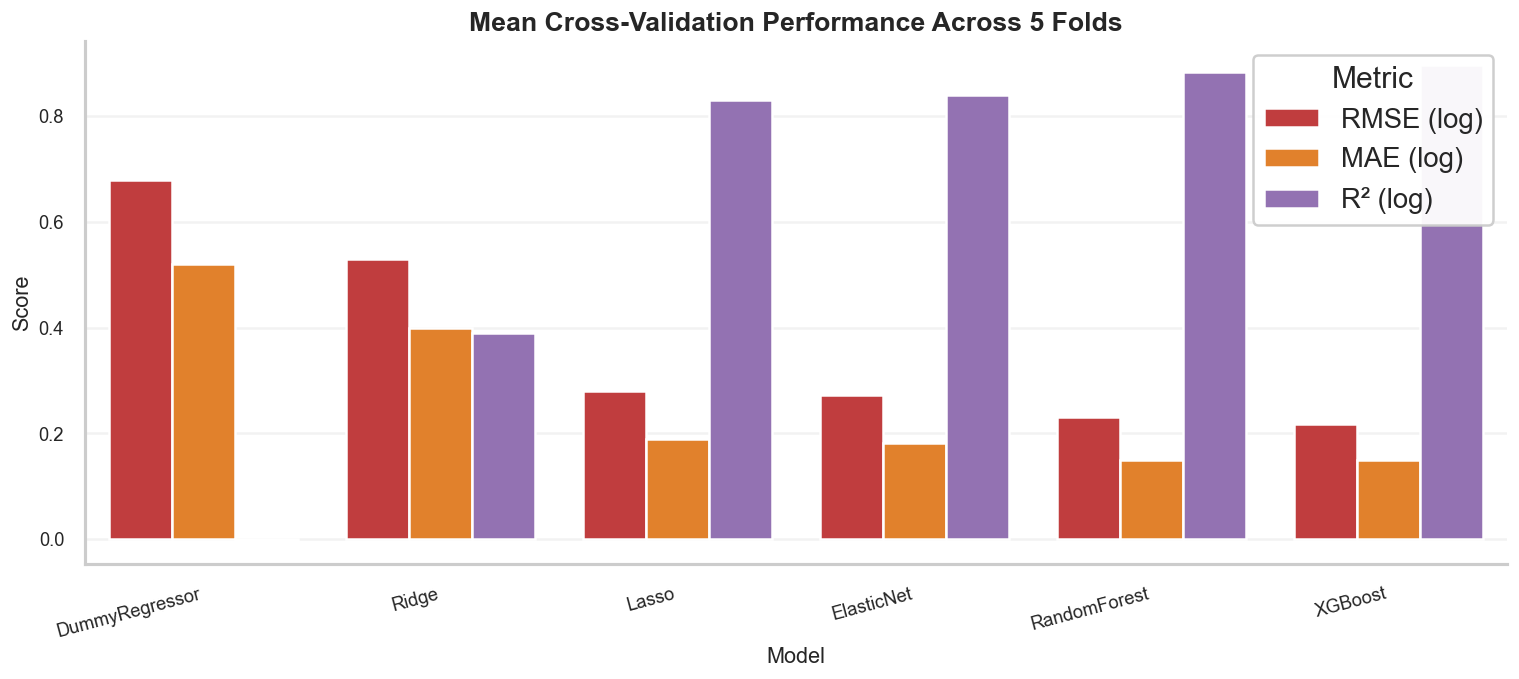

In [16]:
# ============================================================
# Cell 16 — Cross-validated benchmarking and runtime diagnostics
# ============================================================
# Purpose:
# Benchmark all candidate models under identical cross-validation on the
# training data only. This produces fold-level results, ranking summaries,
# stability statistics, and runtime diagnostics for robust and leakage-safe
# model comparison.

SCORING_LOG = {
    "RMSE_log": "neg_root_mean_squared_error",
    "MAE_log": "neg_mean_absolute_error",
    "R2_log": "r2",
}


def cv_evaluate_model(name, pipe, X_train, y_train_log, cv, outer_n_jobs=1):
    """
    Evaluate one model using cross-validation on the log-transformed target.

    Notes
    -----
    - All preprocessing remains inside the pipeline for leakage safety.
    - Outer parallelism is kept at 1 to avoid nested CPU oversubscription.
    """
    start_time = time.time()

    scores = cross_validate(
        estimator=pipe,
        X=X_train,
        y=y_train_log,
        cv=cv,
        scoring=SCORING_LOG,
        n_jobs=outer_n_jobs,
        return_train_score=False,
        error_score="raise",
        pre_dispatch="2*n_jobs"
    )

    total_runtime = time.time() - start_time

    fold_df = pd.DataFrame({
        "model": name,
        "fold": np.arange(1, len(scores["test_RMSE_log"]) + 1),
        "RMSE_log": -scores["test_RMSE_log"],
        "MAE_log": -scores["test_MAE_log"],
        "R2_log": scores["test_R2_log"],
        "fit_time_sec": scores["fit_time"],
        "score_time_sec": scores["score_time"],
    })

    summary_df = pd.DataFrame({
        "model": [name],
        "RMSE_log_mean": [fold_df["RMSE_log"].mean()],
        "RMSE_log_std": [fold_df["RMSE_log"].std(ddof=1)],
        "MAE_log_mean": [fold_df["MAE_log"].mean()],
        "MAE_log_std": [fold_df["MAE_log"].std(ddof=1)],
        "R2_log_mean": [fold_df["R2_log"].mean()],
        "R2_log_std": [fold_df["R2_log"].std(ddof=1)],
        "mean_fit_time_sec": [fold_df["fit_time_sec"].mean()],
        "mean_score_time_sec": [fold_df["score_time_sec"].mean()],
        "total_cv_runtime_sec": [total_runtime],
    })

    return fold_df, summary_df


# ------------------------------------------------------------
# Run benchmarking across all candidate models
# ------------------------------------------------------------
all_fold_results = []
all_summaries = []
failed_models = []

benchmark_start = time.time()

for name, pipe in models.items():
    try:
        fold_df, summary_df = cv_evaluate_model(
            name=name,
            pipe=pipe,
            X_train=X_train,
            y_train_log=y_train_log,
            cv=cv,
            outer_n_jobs=1
        )
        all_fold_results.append(fold_df)
        all_summaries.append(summary_df)
        print(f"Completed CV: {name}")
    except Exception as e:
        failed_models.append({"model": name, "error": str(e)})
        print(f"CV failed for {name}: {e}")

benchmark_elapsed = time.time() - benchmark_start

if not all_fold_results:
    raise RuntimeError(
        "All models failed during cross-validation. Check preprocessing and model pipelines."
    )

cv_results_df = pd.concat(all_fold_results, ignore_index=True)
cv_summary_df = pd.concat(all_summaries, ignore_index=True)

# ------------------------------------------------------------
# Ranking and stability summaries
# ------------------------------------------------------------
cv_rank_df = (
    cv_summary_df
    .sort_values(
        by=["RMSE_log_mean", "MAE_log_mean", "R2_log_mean"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

cv_stability_df = (
    cv_summary_df[[
        "model",
        "RMSE_log_mean",
        "RMSE_log_std",
        "MAE_log_mean",
        "MAE_log_std",
        "R2_log_mean",
        "R2_log_std"
    ]]
    .sort_values(by="RMSE_log_mean")
    .reset_index(drop=True)
)

runtime_df = (
    cv_summary_df[[
        "model",
        "mean_fit_time_sec",
        "mean_score_time_sec",
        "total_cv_runtime_sec"
    ]]
    .sort_values(by="total_cv_runtime_sec")
    .reset_index(drop=True)
)

benchmark_summary = pd.DataFrame({
    "Metric": [
        "Models attempted",
        "Models completed",
        "Models failed",
        "Total benchmark runtime (sec)"
    ],
    "Value": [
        len(models),
        len(cv_summary_df),
        len(failed_models),
        round(benchmark_elapsed, 2)
    ]
})

# ------------------------------------------------------------
# Display main CV outputs
# ------------------------------------------------------------
display(style_table(benchmark_summary))
display(cv_results_df.head(10).round(4))
display(
    style_table(
        cv_rank_df.round(4),
        gradient_subset=["RMSE_log_mean", "MAE_log_mean", "R2_log_mean"]
    )
)
display(
    style_table(
        cv_stability_df.round(4),
        gradient_subset=["RMSE_log_std", "MAE_log_std", "R2_log_std"]
    )
)
display(
    style_table(
        runtime_df.round(3),
        gradient_subset=["total_cv_runtime_sec"]
    )
)

if failed_models:
    failed_models_df = pd.DataFrame(failed_models)
    display(style_table(failed_models_df))

# ------------------------------------------------------------
# Interpretation of CV findings
# ------------------------------------------------------------
best_cv_model = cv_rank_df.iloc[0]["model"]
best_cv_rmse = float(cv_rank_df.iloc[0]["RMSE_log_mean"])
best_cv_mae = float(cv_rank_df.iloc[0]["MAE_log_mean"])
best_cv_r2 = float(cv_rank_df.iloc[0]["R2_log_mean"])

most_stable_model = cv_stability_df.sort_values(
    by=["RMSE_log_std", "MAE_log_std"],
    ascending=[True, True]
).iloc[0]["model"]

print(
    f"Interpretation: {best_cv_model} achieves the strongest mean cross-validation "
    f"performance on the training data (RMSE_log = {best_cv_rmse:.4f}, "
    f"MAE_log = {best_cv_mae:.4f}, R²_log = {best_cv_r2:.4f}). "
    "This suggests the strongest expected generalisation across unseen folds."
)

print(
    f"Stability note: {most_stable_model} shows the lowest fold-to-fold variation overall, "
    "indicating more consistent performance across resampled training splits."
)

print(
    "In this benchmark, lower RMSE and MAE indicate better predictive accuracy on the "
    "log-transformed target, while lower standard deviation indicates greater stability."
)

# ------------------------------------------------------------
# Performance comparison plot
# ------------------------------------------------------------
cv_plot_df = cv_summary_df[[
    "model",
    "RMSE_log_mean",
    "MAE_log_mean",
    "R2_log_mean"
]].copy()

cv_plot_long = cv_plot_df.melt(
    id_vars="model",
    value_vars=["RMSE_log_mean", "MAE_log_mean", "R2_log_mean"],
    var_name="Metric",
    value_name="Value"
)

metric_label_map = {
    "RMSE_log_mean": "RMSE (log)",
    "MAE_log_mean": "MAE (log)",
    "R2_log_mean": "R² (log)"
}
cv_plot_long["Metric"] = cv_plot_long["Metric"].map(metric_label_map)

fig, ax = plt.subplots(figsize=(13, 6))

if SEABORN_OK:
    sns.barplot(
        data=cv_plot_long,
        x="model",
        y="Value",
        hue="Metric",
        palette=[COLORS["highlight"], COLORS["secondary"], COLORS["purple"]],
        ax=ax
    )
else:
    model_order = cv_plot_df["model"].tolist()
    x = np.arange(len(model_order))
    width = 0.25

    ax.bar(
        x - width,
        cv_plot_df["RMSE_log_mean"],
        width=width,
        color=COLORS["highlight"],
        label="RMSE (log)"
    )
    ax.bar(
        x,
        cv_plot_df["MAE_log_mean"],
        width=width,
        color=COLORS["secondary"],
        label="MAE (log)"
    )
    ax.bar(
        x + width,
        cv_plot_df["R2_log_mean"],
        width=width,
        color=COLORS["purple"],
        label="R² (log)"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(model_order)

ax.set_title(f"Mean Cross-Validation Performance Across {CV_FOLDS} Folds")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.legend(title="Metric")
format_axis(ax, rotate_xticks=15)

show_and_save(fig, "figure_06_cv_model_comparison.png")

In [17]:
# ============================================================
# Cell 17 — Faster hyperparameter tuning of strongest candidate models
# ============================================================
# Purpose:
# Tune the strongest candidate models using a computationally efficient
# RandomizedSearchCV design on training data only. This preserves leakage
# safety while keeping runtime practical for submission.


ranked_models = cv_rank_df["model"].tolist()

preferred_nonlinear_order = ["XGBoost", "RandomForest"]
preferred_linear_order = ["ElasticNet", "Ridge", "Lasso"]

selected_to_tune = []

for model_name in preferred_nonlinear_order:
    if model_name in ranked_models:
        selected_to_tune.append(model_name)
        break

for model_name in preferred_linear_order:
    if model_name in ranked_models:
        selected_to_tune.append(model_name)
        break

# Fallback: if fewer than 2 were selected, fill from ranked tunable models
tunable_pool = {"ElasticNet", "RandomForest", "XGBoost", "Ridge", "Lasso"}
for model_name in ranked_models:
    if model_name in tunable_pool and model_name not in selected_to_tune:
        selected_to_tune.append(model_name)
    if len(selected_to_tune) == 2:
        break

top_models_to_tune = selected_to_tune[:2]

tuning_cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

param_spaces = {
    "Ridge": {
        "model__alpha": [0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
    },
    "Lasso": {
        "model__alpha": [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005]
    },
    "ElasticNet": {
        "model__alpha": [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005],
        "model__l1_ratio": [0.2, 0.35, 0.5, 0.65, 0.8]
    },
    "RandomForest": {
        "model__n_estimators": [160, 180, 220, 260],
        "model__max_depth": [None, 10, 14, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.7, 0.8]
    },
    "XGBoost": {
        "model__n_estimators": [160, 220, 300, 360],
        "model__learning_rate": [0.03, 0.05, 0.07, 0.08],
        "model__max_depth": [4, 5, 6, 8],
        "model__min_child_weight": [1, 2, 4],
        "model__subsample": [0.7, 0.8, 0.9],
        "model__colsample_bytree": [0.7, 0.8, 0.9],
        "model__reg_lambda": [0.5, 1.0, 2.0, 3.0]
    }
}

n_iter_lookup = {
    "Ridge": 6,
    "Lasso": 6,
    "ElasticNet": 8,
    "RandomForest": 10,
    "XGBoost": 12,
}

tuned_models = {name: pipe for name, pipe in models.items()}
tuning_records = []

for name in top_models_to_tune:
    if name not in param_spaces:
        continue

    pipe = models[name]

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_spaces[name],
        n_iter=n_iter_lookup.get(name, 6),
        scoring="neg_root_mean_squared_error",
        cv=tuning_cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=0,
        refit=True,
        error_score="raise"
    )

    start_time = time.time()
    search.fit(X_train, y_train_log)
    elapsed = time.time() - start_time

    tuned_models[name] = search.best_estimator_

    tuning_records.append({
        "model": name,
        "tuning_folds": tuning_cv.get_n_splits(),
        "n_iter": n_iter_lookup.get(name, 6),
        "best_cv_rmse_log": round(float(-search.best_score_), 4),
        "elapsed_sec": round(float(elapsed), 2),
        "best_params": search.best_params_
    })

tuning_df = pd.DataFrame(tuning_records)

if tuning_df.empty:
    print("No candidate models were selected for tuning.")
else:
    tuning_df = tuning_df.sort_values(by="best_cv_rmse_log", ascending=True).reset_index(drop=True)

    display(style_table(tuning_df))

    print(
        "Tuning complete: the strongest candidate models were optimised using a smaller "
        "3-fold search design to balance model quality and computational efficiency."
    )

    best_tuned_model_name = tuning_df.iloc[0]["model"]
    best_tuned_rmse = float(tuning_df.iloc[0]["best_cv_rmse_log"])

    print(
        f"Best tuned candidate: {best_tuned_model_name} "
        f"(CV RMSE_log = {best_tuned_rmse:.4f})."
    )

,model,tuning_folds,n_iter,best_cv_rmse_log,elapsed_sec,best_params
0,XGBoost,3,12,0.205200,92.550000,"{'model__subsample': 0.8, 'model__reg_lambda': 0.5, 'model__n_estimators': 300, 'model__min_child_weight': 2, 'model__max_depth': 8, 'model__learning_rate': 0.07, 'model__colsample_bytree': 0.9}"
1,ElasticNet,3,8,0.273800,362.150000,"{'model__l1_ratio': 0.65, 'model__alpha': 0.0003}"


Tuning complete: the strongest candidate models were optimised using a smaller 3-fold search design to balance model quality and computational efficiency.
Best tuned candidate: XGBoost (CV RMSE_log = 0.2052).


,model,RMSE_AUD,MAE_AUD,R2_AUD,RMSE_log,MAE_log,R2_log
0,XGBoost,13700.545500,5070.005300,0.842000,0.192800,0.129900,0.919300
1,RandomForest,16516.850400,5818.939500,0.770300,0.227200,0.148500,0.887900
2,ElasticNet,18324.286500,7187.468600,0.717300,0.254900,0.175200,0.859000
3,Lasso,19396.014700,7686.278300,0.683300,0.271500,0.188800,0.840000
4,Ridge,32384.435200,15016.263100,0.117100,0.526800,0.394900,0.397600
5,DummyRegressor,35300.435600,18472.298200,-0.049000,0.678900,0.521900,-0.000500


,Metric,Value
0,Best model on test set,XGBoost
1,Best RMSE (AUD),13700.550000
2,Best MAE (AUD),5070.010000
3,Best R² (AUD),0.842000
4,Models evaluated,6


Key takeaway: XGBoost achieves the strongest locked test-set performance, indicating that it generalises best to unseen vehicle listings in this study.
Best-model RMSE as a percentage of mean test price: 36.90%
[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_07_test_set_rmse_comparison.png


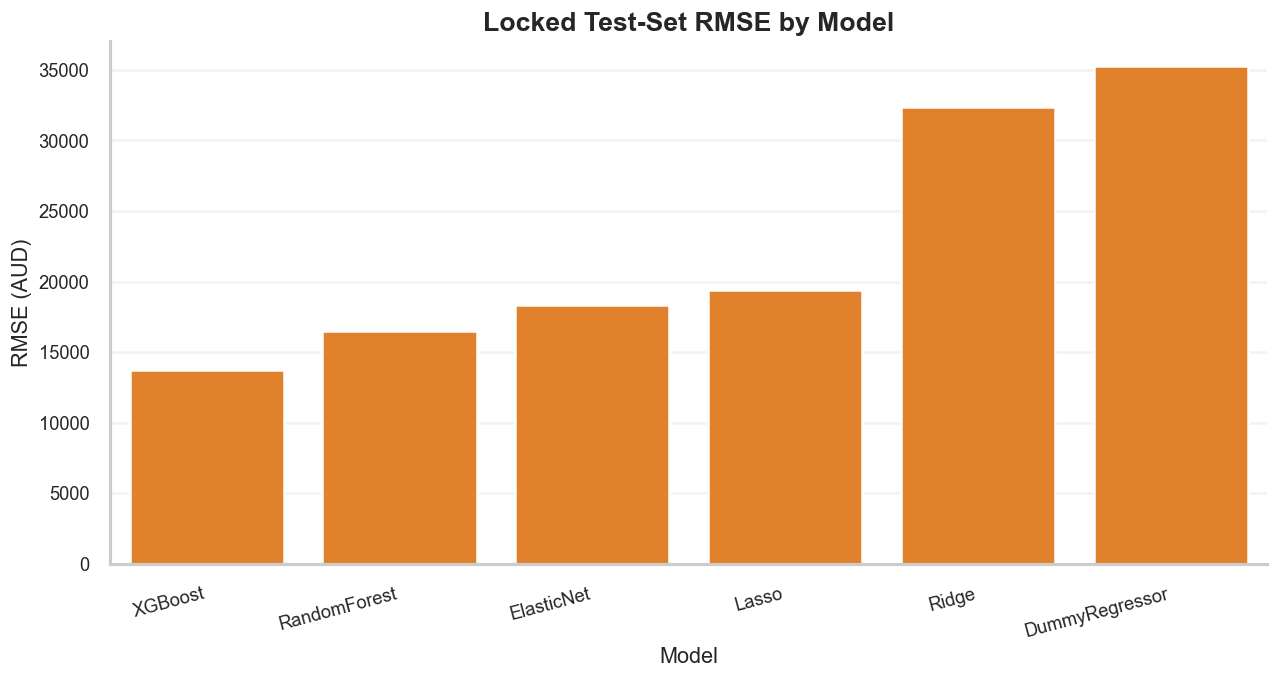

In [18]:
# ============================================================
# Cell 18 — Locked test-set evaluation on original AUD scale
# ============================================================
# Purpose:
# Evaluate all baseline and tuned models on the untouched hold-out
# test set and report results on the original AUD scale. This is
# the final unbiased comparison used for conclusions.

evaluation_models = tuned_models if "tuned_models" in globals() else models

test_results = []
test_predictions = {}

for name, pipe in evaluation_models.items():
    fitted_model = pipe.fit(X_train, y_train_log)

    pred_log = fitted_model.predict(X_test)
    pred_aud = inverse_log_predictions(pred_log)

    metrics_aud = regression_metrics_aud(y_test_raw, pred_aud)
    metrics_log = regression_metrics_log(y_test_log, pred_log)

    result = {"model": name}
    result.update(metrics_aud)
    result.update(metrics_log)
    test_results.append(result)

    test_predictions[name] = {
        "y_pred_log": pred_log,
        "y_pred_aud": pred_aud
    }

test_results_df = (
    pd.DataFrame(test_results)
    .sort_values(by=["RMSE_AUD", "MAE_AUD", "R2_AUD"], ascending=[True, True, False])
    .reset_index(drop=True)
)

display(
    style_table(
        test_results_df.round(4),
        gradient_subset=["RMSE_AUD", "MAE_AUD", "R2_AUD"]
    )
)

best_model_name = test_results_df.iloc[0]["model"]
best_model = evaluation_models[best_model_name].fit(X_train, y_train_log)

comparison_summary = pd.DataFrame({
    "Metric": [
        "Best model on test set",
        "Best RMSE (AUD)",
        "Best MAE (AUD)",
        "Best R² (AUD)",
        "Models evaluated"
    ],
    "Value": [
        best_model_name,
        round(float(test_results_df.iloc[0]["RMSE_AUD"]), 2),
        round(float(test_results_df.iloc[0]["MAE_AUD"]), 2),
        round(float(test_results_df.iloc[0]["R2_AUD"]), 4),
        len(test_results_df)
    ]
})

display(style_table(comparison_summary))

print(
    f"Key takeaway: {best_model_name} achieves the strongest locked test-set performance, "
    "indicating that it generalises best to unseen vehicle listings in this study."
)

best_rmse_pct = (float(test_results_df.iloc[0]["RMSE_AUD"]) / float(y_test_raw.mean())) * 100
print(f"Best-model RMSE as a percentage of mean test price: {best_rmse_pct:.2f}%")

# -----------------------------
# Test-set leaderboard plot
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

plot_df = test_results_df.copy()

if SEABORN_OK:
    sns.barplot(
        data=plot_df,
        x="model",
        y="RMSE_AUD",
        color=COLORS["secondary"],
        ax=ax
    )
else:
    ax.bar(plot_df["model"], plot_df["RMSE_AUD"], color=COLORS["secondary"])

ax.set_title("Locked Test-Set RMSE by Model")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE (AUD)")
ax.ticklabel_format(style="plain", axis="y")
format_axis(ax, rotate_xticks=15)

show_and_save(fig, "figure_07_test_set_rmse_comparison.png")

,Metric,Value
0,Best model,XGBoost
1,Mean actual price,37131.880000
2,Mean predicted price,36009.790000
3,Mean residual,1122.100000
4,Median residual,-71.080000
5,Mean absolute error,5070.010000
6,Median absolute error,2420.670000
7,Mean percentage error,13.090000


,price_band,n,MAE_AUD,RMSE_AUD,median_abs_error,mean_pct_error,mean_signed_pct_error
0,Low,1102,2230.560000,3172.170000,1658.650000,16.850000,-8.620000
1,Mid,1101,2967.420000,4091.500000,2211.120000,10.100000,-0.130000
2,High,1134,9870.720000,22941.750000,4996.010000,12.340000,3.740000


,BodyType,n,MAE_AUD,median_price
0,Coupe,66,22695.709295,43495.000000
1,nan,58,7308.685252,24444.000000
2,Commercial,132,6482.990153,31450.000000
3,Wagon,250,6235.133621,23992.500000
4,Ute / Tray,486,5218.997909,34985.000000
5,Sedan,379,4755.562826,24990.000000
6,SUV,1409,4454.649833,32888.000000
7,Hatchback,525,2619.325020,20888.000000


Interpretation: Prediction accuracy is strongest in the low and middle price segments and weaker in the high-price segment, indicating greater uncertainty and heterogeneity among premium vehicles.
Observation: Residual spread increases with predicted price, suggesting heteroscedastic behaviour in practical terms, where expensive vehicles are harder to value accurately.
[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_08_predicted_vs_actual_best_model.png


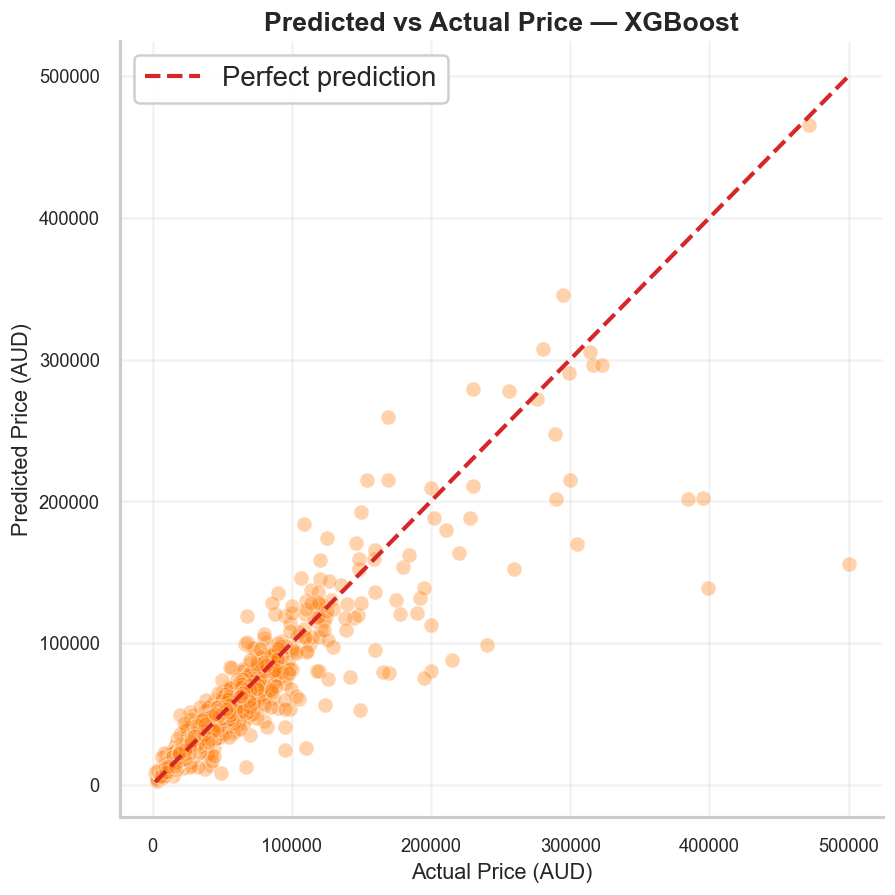

[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_09_residual_diagnostics_best_model.png


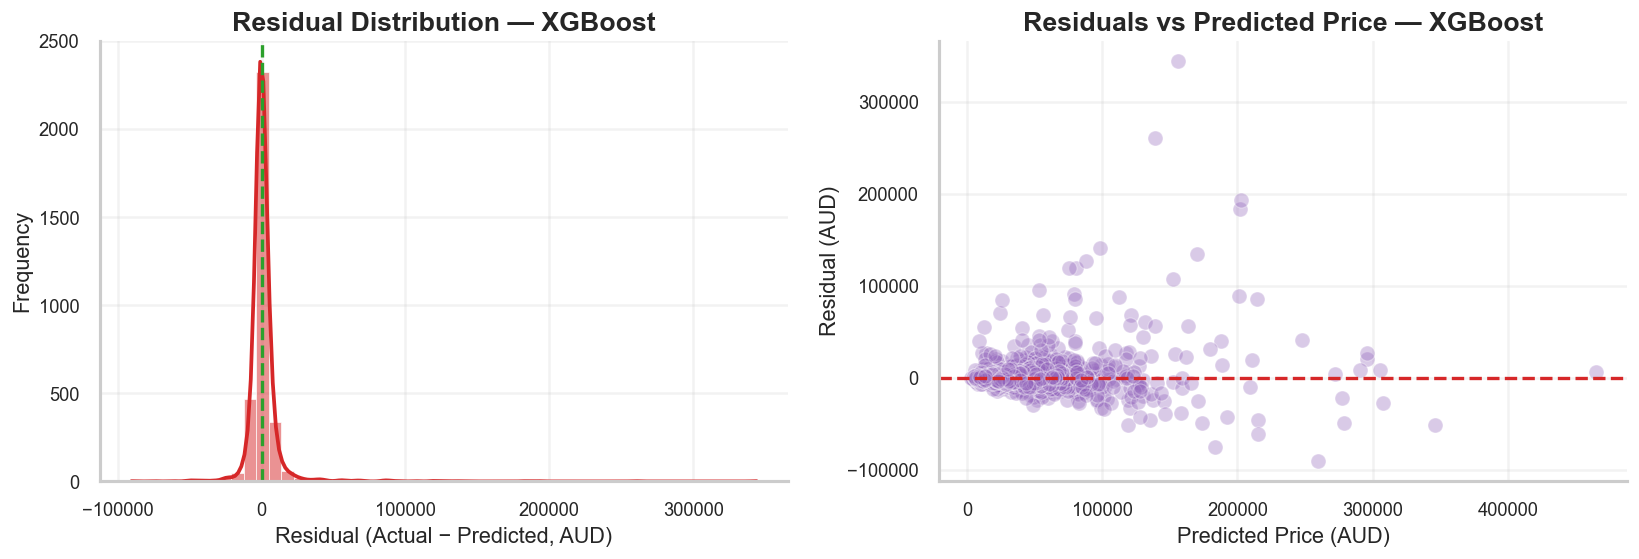

C:\Users\girid\AppData\Local\Temp\ipykernel_33952\2051031583.py:230: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_10_mae_by_price_band_best_model.png


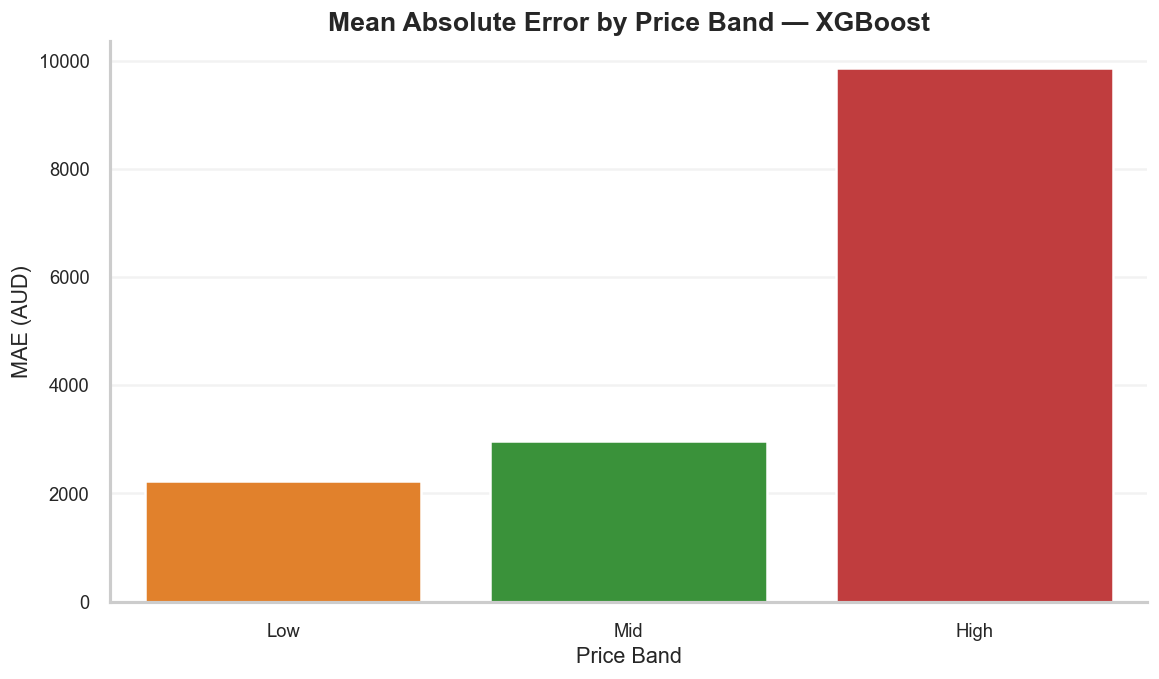

,Brand,n,MAE_AUD,median_price
0,Toyota,530,4527.488981,33689.000000
1,Isuzu,46,5178.217731,38845.000000
2,Lexus,36,5468.816108,49489.500000
3,Ford,205,6409.827603,28990.000000
4,Volvo,33,6599.428474,49990.000000
5,Jeep,60,7091.118848,31490.000000
6,Audi,88,8371.828058,41766.500000
7,BMW,100,8466.651763,38859.000000
8,Mercedes-Benz,124,14177.029124,42990.000000
9,Land,46,14613.786303,57399.500000


[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_11_mae_by_brand_top10_best_model.png


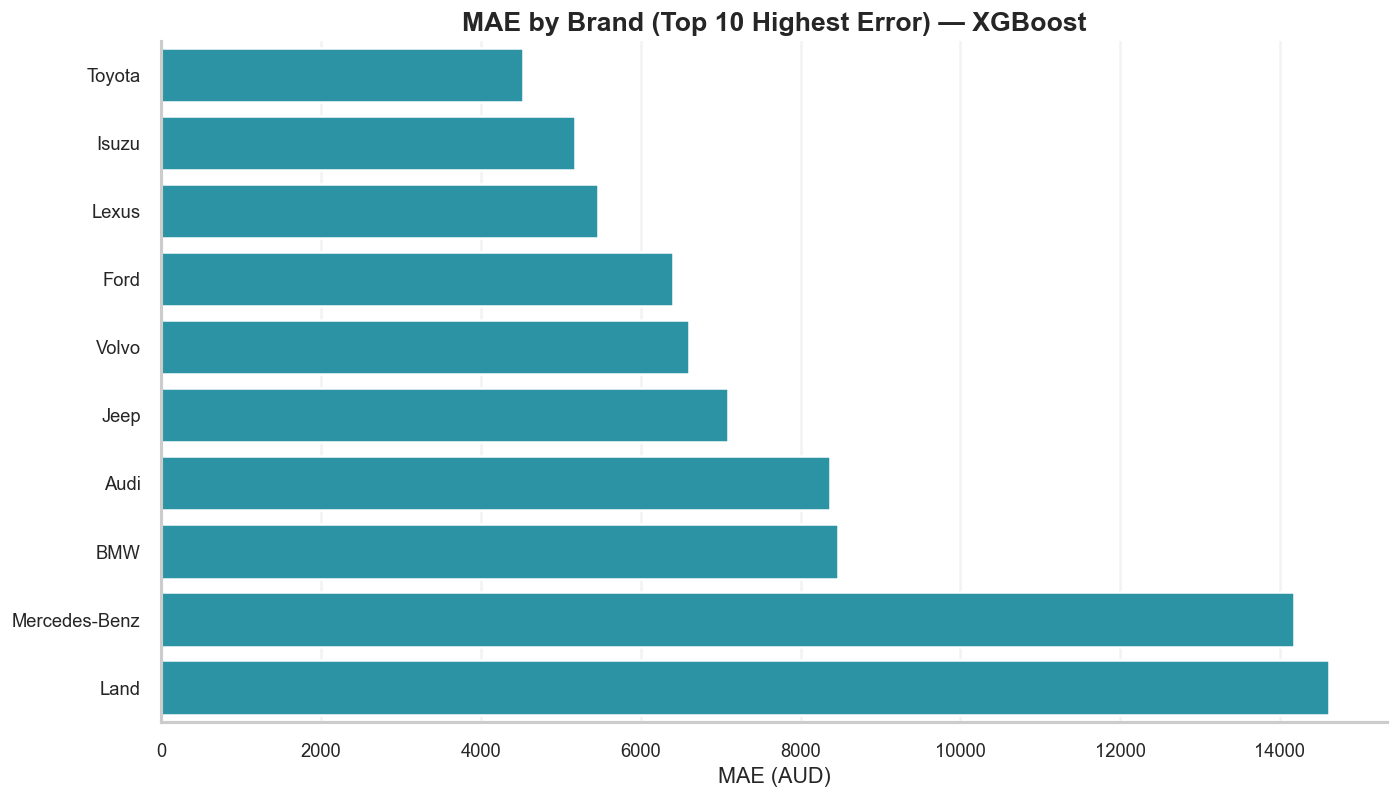

In [19]:
# ============================================================
# Cell 19 — Model diagnostics for the best test model
# ============================================================
# Purpose:
# Evaluate the best test-set model in depth using actual-vs-predicted
# analysis, residual diagnostics, error segmentation by price band,
# and brand-level robustness checks.

best_pred_aud = test_predictions[best_model_name]["y_pred_aud"]

diagnostic_df = pd.DataFrame({
    "actual_price": y_test_raw.values,
    "predicted_price": best_pred_aud
})

diagnostic_df["residual"] = diagnostic_df["actual_price"] - diagnostic_df["predicted_price"]
diagnostic_df["absolute_error"] = diagnostic_df["residual"].abs()
diagnostic_df["percentage_error"] = (
    diagnostic_df["absolute_error"] / np.maximum(diagnostic_df["actual_price"], 1) * 100
)

diagnostic_df["signed_percentage_error"] = (
    diagnostic_df["residual"] / np.maximum(diagnostic_df["actual_price"], 1) * 100
)

diagnostic_summary = pd.DataFrame({
    "Metric": [
        "Best model",
        "Mean actual price",
        "Mean predicted price",
        "Mean residual",
        "Median residual",
        "Mean absolute error",
        "Median absolute error",
        "Mean percentage error"
    ],
    "Value": [
        best_model_name,
        round(float(diagnostic_df["actual_price"].mean()), 2),
        round(float(diagnostic_df["predicted_price"].mean()), 2),
        round(float(diagnostic_df["residual"].mean()), 2),
        round(float(diagnostic_df["residual"].median()), 2),
        round(float(diagnostic_df["absolute_error"].mean()), 2),
        round(float(diagnostic_df["absolute_error"].median()), 2),
        round(float(diagnostic_df["percentage_error"].mean()), 2)
    ]
})

display(style_table(diagnostic_summary))

# ------------------------------------------------------------
# Error by price band
# ------------------------------------------------------------
q33, q66 = diagnostic_df["actual_price"].quantile([0.33, 0.66]).values

def price_band(v):
    if v <= q33:
        return "Low"
    if v <= q66:
        return "Mid"
    return "High"

diagnostic_df["price_band"] = diagnostic_df["actual_price"].apply(price_band)

band_summary = (
    diagnostic_df.groupby("price_band")
    .agg(
        n=("absolute_error", "size"),
        MAE_AUD=("absolute_error", "mean"),
        RMSE_AUD=("residual", lambda x: float(np.sqrt(np.mean(np.square(x))))),
        median_abs_error=("absolute_error", "median"),
        mean_pct_error=("percentage_error", "mean"),
        mean_signed_pct_error=("signed_percentage_error", "mean")
    )
    .reindex(["Low", "Mid", "High"])
    .round(2)
    .reset_index()
)

display(style_table(band_summary))

# ------------------------------------------------------------
# Optional error by body type
# ------------------------------------------------------------
body_summary = None
if "BodyType" in X_test.columns:
    err_body = pd.DataFrame({
        "BodyType": X_test["BodyType"].astype(str).fillna("Unknown").values,
        "absolute_error": diagnostic_df["absolute_error"].values,
        "actual_price": diagnostic_df["actual_price"].values
    })

    body_summary = (
        err_body.groupby("BodyType")
        .agg(
            n=("absolute_error", "size"),
            MAE_AUD=("absolute_error", "mean"),
            median_price=("actual_price", "median")
        )
        .reset_index()
    )

    body_summary = body_summary[body_summary["n"] >= 30].copy()

    if not body_summary.empty:
        top_body_summary = (
            body_summary.sort_values("MAE_AUD", ascending=False)
            .head(10)
            .reset_index(drop=True)
        )
        display(style_table(top_body_summary))

# ------------------------------------------------------------
# Diagnostic interpretation
# ------------------------------------------------------------
print(
    "Interpretation: Prediction accuracy is strongest in the low and middle price segments "
    "and weaker in the high-price segment, indicating greater uncertainty and heterogeneity "
    "among premium vehicles."
)

print(
    "Observation: Residual spread increases with predicted price, suggesting heteroscedastic "
    "behaviour in practical terms, where expensive vehicles are harder to value accurately."
)

# -----------------------------
# Predicted vs actual
# -----------------------------
fig, ax = plt.subplots(figsize=(7.8, 7.8))

if SEABORN_OK:
    sns.scatterplot(
        x=diagnostic_df["actual_price"],
        y=diagnostic_df["predicted_price"],
        alpha=0.35,
        color=COLORS["secondary"],
        ax=ax
    )
else:
    ax.scatter(
        diagnostic_df["actual_price"],
        diagnostic_df["predicted_price"],
        alpha=0.35,
        color=COLORS["secondary"]
    )

min_lim = float(min(diagnostic_df["actual_price"].min(), diagnostic_df["predicted_price"].min()))
max_lim = float(max(diagnostic_df["actual_price"].max(), diagnostic_df["predicted_price"].max()))

ax.plot(
    [min_lim, max_lim],
    [min_lim, max_lim],
    linestyle="--",
    linewidth=2.5,
    color=COLORS["highlight"],
    label="Perfect prediction"
)

ax.set_title(f"Predicted vs Actual Price — {best_model_name}")
ax.set_xlabel("Actual Price (AUD)")
ax.set_ylabel("Predicted Price (AUD)")
ax.ticklabel_format(style="plain", axis="both")
ax.legend(loc="upper left")
format_axis(ax)

show_and_save(fig, "figure_08_predicted_vs_actual_best_model.png")

# -----------------------------
# Residual diagnostics
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if SEABORN_OK:
    sns.histplot(
        diagnostic_df["residual"],
        bins=50,
        kde=True,
        ax=axes[0],
        color=COLORS["highlight"],
        edgecolor="white",
        linewidth=0.4
    )
else:
    axes[0].hist(
        diagnostic_df["residual"],
        bins=50,
        color=COLORS["highlight"],
        edgecolor="white",
        linewidth=0.4
    )

axes[0].axvline(0, linestyle="--", linewidth=2, color=COLORS["accent"])
axes[0].set_title(f"Residual Distribution — {best_model_name}")
axes[0].set_xlabel("Residual (Actual − Predicted, AUD)")
axes[0].set_ylabel("Frequency")
format_axis(axes[0])

if SEABORN_OK:
    sns.scatterplot(
        x=diagnostic_df["predicted_price"],
        y=diagnostic_df["residual"],
        alpha=0.35,
        ax=axes[1],
        color=COLORS["purple"]
    )
else:
    axes[1].scatter(
        diagnostic_df["predicted_price"],
        diagnostic_df["residual"],
        alpha=0.35,
        color=COLORS["purple"]
    )

axes[1].axhline(0, linestyle="--", linewidth=2, color=COLORS["highlight"])
axes[1].set_title(f"Residuals vs Predicted Price — {best_model_name}")
axes[1].set_xlabel("Predicted Price (AUD)")
axes[1].set_ylabel("Residual (AUD)")
axes[1].ticklabel_format(style="plain", axis="x")
format_axis(axes[1])

show_and_save(fig, "figure_09_residual_diagnostics_best_model.png")

# -----------------------------
# MAE by price band
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

if SEABORN_OK:
    sns.barplot(
        data=band_summary,
        x="price_band",
        y="MAE_AUD",
        palette=[COLORS["secondary"], COLORS["accent"], COLORS["highlight"]],
        ax=ax
    )
else:
    ax.bar(
        band_summary["price_band"],
        band_summary["MAE_AUD"],
        color=[COLORS["secondary"], COLORS["accent"], COLORS["highlight"]]
    )

ax.set_title(f"Mean Absolute Error by Price Band — {best_model_name}")
ax.set_xlabel("Price Band")
ax.set_ylabel("MAE (AUD)")
format_axis(ax)

show_and_save(fig, "figure_10_mae_by_price_band_best_model.png")

# -----------------------------
# Optional brand-level robustness
# -----------------------------
brand_candidates = ["Brand", "Make", "Manufacturer", "brand", "make"]
BRAND_COL = next((c for c in brand_candidates if c in X_test.columns), None)

brand_summary = None
top10_brand_error = None

if BRAND_COL is not None:
    err_brand = pd.DataFrame({
        BRAND_COL: X_test[BRAND_COL].astype(str).fillna("Unknown").values,
        "absolute_error": diagnostic_df["absolute_error"].values,
        "actual_price": diagnostic_df["actual_price"].values
    })

    brand_summary = (
        err_brand.groupby(BRAND_COL)
        .agg(
            n=("absolute_error", "size"),
            MAE_AUD=("absolute_error", "mean"),
            median_price=("actual_price", "median")
        )
        .reset_index()
    )

    MIN_N = 30
    brand_summary = brand_summary[brand_summary["n"] >= MIN_N].copy()

    if not brand_summary.empty:
        top10_brand_error = (
            brand_summary
            .sort_values("MAE_AUD", ascending=False)
            .head(10)
            .sort_values("MAE_AUD", ascending=True)
            .reset_index(drop=True)
        )

        display(style_table(top10_brand_error))

        fig, ax = plt.subplots(figsize=(12, 7))

        if SEABORN_OK:
            sns.barplot(
                data=top10_brand_error,
                x="MAE_AUD",
                y=BRAND_COL,
                color=COLORS["teal"],
                ax=ax
            )
        else:
            ax.barh(
                top10_brand_error[BRAND_COL],
                top10_brand_error["MAE_AUD"],
                color=COLORS["teal"]
            )

        ax.set_title(f"MAE by Brand (Top 10 Highest Error) — {best_model_name}")
        ax.set_xlabel("MAE (AUD)")
        ax.set_ylabel("")
        ax.ticklabel_format(style="plain", axis="x")
        format_axis(ax)

        show_and_save(fig, "figure_11_mae_by_brand_top10_best_model.png")
else:
    print("No brand-like column found in X_test for brand-level robustness analysis.")

,feature,importance_mean,importance_std
0,Year,0.377200,0.004700
1,Kilometres_EDA,0.095700,0.001000
2,Engine,0.085000,0.002800
3,DriveType,0.081600,0.003000
4,Brand,0.070100,0.001300
5,CylindersinEngine,0.063000,0.003700
6,FuelType,0.038800,0.002700
7,Kilometres,0.032200,0.001800
8,Model,0.023900,0.001000
9,FuelConsumption,0.023300,0.000900


Interpretation: Year is the most influential raw input feature (permutation importance = 0.3772). At this stage, importance should be interpreted as the contribution of the original input columns passed into the full pipeline.
[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_12_permutation_importance.png


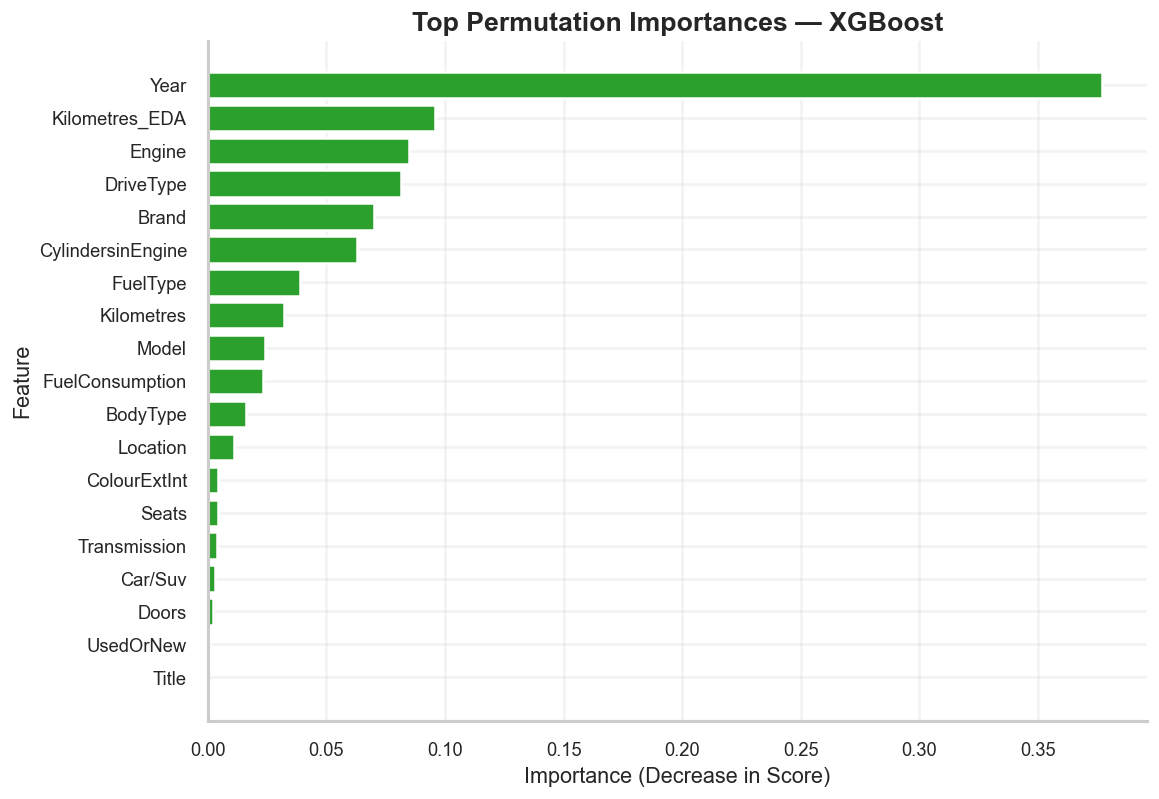

In [20]:
# ============================================================
# Cell 20 — Permutation importance on held-out validation from training data
# ============================================================
# Purpose:
# Estimate permutation importance using a validation split taken
# only from the training data. This preserves the purity of the
# locked test set while still providing a leakage-safe and
# model-agnostic view of important predictive drivers.
#
# Note:
# Because permutation is applied to the raw validation input passed
# through the full pipeline, importance is interpreted at the level
# of the original input columns rather than individual one-hot encoded
# or engineered internal features.

X_tr_pi, X_va_pi, y_tr_pi_raw, y_va_pi_raw = train_test_split(
    X_train,
    y_train_raw,
    test_size=0.20,
    random_state=RANDOM_STATE
)

y_tr_pi_log = np.log1p(y_tr_pi_raw)
y_va_pi_log = np.log1p(y_va_pi_raw)

best_pipe_for_importance = best_model
best_pipe_for_importance.fit(X_tr_pi, y_tr_pi_log)

perm = permutation_importance(
    estimator=best_pipe_for_importance,
    X=X_va_pi,
    y=y_va_pi_log,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

feature_names = list(X_va_pi.columns)

if len(feature_names) != len(perm.importances_mean):
    feature_names = [f"feature_{i}" for i in range(len(perm.importances_mean))]

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

top_importance_df = importance_df.head(20).copy()
display(style_table(top_importance_df.round(4)))

top_feature = top_importance_df.iloc[0]["feature"]
top_value = float(top_importance_df.iloc[0]["importance_mean"])

print(
    f"Interpretation: {top_feature} is the most influential raw input feature "
    f"(permutation importance = {top_value:.4f}). At this stage, importance should "
    "be interpreted as the contribution of the original input columns passed into the full pipeline."
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_importance_df["feature"].astype(str)[::-1],
    top_importance_df["importance_mean"][::-1],
    color=COLORS["accent"]
)

ax.set_title(f"Top Permutation Importances — {best_model_name}")
ax.set_xlabel("Importance (Decrease in Score)")
ax.set_ylabel("Feature")
format_axis(ax)

show_and_save(fig, "figure_12_permutation_importance.png")

In [21]:
# ============================================================
# Cell 21 — Final integrated model comparison
# ============================================================
# Purpose:
# Combine cross-validation performance and locked test-set performance
# into one final comparison table. This creates a single thesis-ready
# summary of model selection behaviour versus final generalisation.

cv_lookup = cv_summary_df.set_index("model")[[
    "RMSE_log_mean",
    "MAE_log_mean",
    "R2_log_mean",
    "RMSE_log_std",
    "MAE_log_std",
    "R2_log_std"
]]

final_comparison_df = test_results_df.copy()

final_comparison_df["CV_RMSE_log_mean"] = final_comparison_df["model"].map(cv_lookup["RMSE_log_mean"])
final_comparison_df["CV_MAE_log_mean"] = final_comparison_df["model"].map(cv_lookup["MAE_log_mean"])
final_comparison_df["CV_R2_log_mean"] = final_comparison_df["model"].map(cv_lookup["R2_log_mean"])
final_comparison_df["CV_RMSE_log_std"] = final_comparison_df["model"].map(cv_lookup["RMSE_log_std"])
final_comparison_df["CV_MAE_log_std"] = final_comparison_df["model"].map(cv_lookup["MAE_log_std"])
final_comparison_df["CV_R2_log_std"] = final_comparison_df["model"].map(cv_lookup["R2_log_std"])

final_comparison_df["RMSE_AUD_as_pct_of_mean_test_price"] = (
    final_comparison_df["RMSE_AUD"] / float(y_test_raw.mean()) * 100
)

final_comparison_df = final_comparison_df[[
    "model",
    "CV_RMSE_log_mean",
    "CV_RMSE_log_std",
    "CV_MAE_log_mean",
    "CV_MAE_log_std",
    "CV_R2_log_mean",
    "CV_R2_log_std",
    "RMSE_AUD",
    "MAE_AUD",
    "R2_AUD",
    "RMSE_AUD_as_pct_of_mean_test_price",
    "RMSE_log",
    "MAE_log",
    "R2_log"
]].sort_values(by="RMSE_AUD").reset_index(drop=True)

best_row = final_comparison_df.iloc[0].copy()

final_summary_df = pd.DataFrame({
    "Metric": [
        "Best model on test set",
        "Best RMSE (AUD)",
        "Best MAE (AUD)",
        "Best R² (AUD)",
        "Best CV RMSE (log)",
        "Best CV MAE (log)",
        "Best CV R² (log)",
        "Best RMSE as % of mean test price"
    ],
    "Value": [
        best_row["model"],
        round(float(best_row["RMSE_AUD"]), 2),
        round(float(best_row["MAE_AUD"]), 2),
        round(float(best_row["R2_AUD"]), 4),
        round(float(best_row["CV_RMSE_log_mean"]), 4),
        round(float(best_row["CV_MAE_log_mean"]), 4),
        round(float(best_row["CV_R2_log_mean"]), 4),
        round(float(best_row["RMSE_AUD_as_pct_of_mean_test_price"]), 2)
    ]
})

display(
    style_table(
        final_comparison_df.round(4),
        gradient_subset=[
            "CV_RMSE_log_mean",
            "CV_MAE_log_mean",
            "CV_R2_log_mean",
            "RMSE_AUD",
            "MAE_AUD",
            "R2_AUD",
            "RMSE_AUD_as_pct_of_mean_test_price"
        ]
    )
)
display(style_table(final_summary_df))

print(
    "Final comparison summary prepared: this table combines resampled training performance "
    "with locked test-set generalisation, allowing a direct comparison between model selection "
    "behaviour and final unseen-data performance."
)

,model,CV_RMSE_log_mean,CV_RMSE_log_std,CV_MAE_log_mean,CV_MAE_log_std,CV_R2_log_mean,CV_R2_log_std,RMSE_AUD,MAE_AUD,R2_AUD,RMSE_AUD_as_pct_of_mean_test_price,RMSE_log,MAE_log,R2_log
0,XGBoost,0.217300,0.009900,0.148800,0.001400,0.897000,0.009400,13700.545500,5070.005300,0.842000,36.897000,0.192800,0.129900,0.919300
1,RandomForest,0.231500,0.009200,0.149900,0.003000,0.883100,0.008300,16516.850400,5818.939500,0.770300,44.481600,0.227200,0.148500,0.887900
2,ElasticNet,0.271500,0.014900,0.181500,0.002300,0.839100,0.016500,18324.286500,7187.468600,0.717300,49.349200,0.254900,0.175200,0.859000
3,Lasso,0.279900,0.014200,0.188400,0.002200,0.829100,0.016200,19396.014700,7686.278300,0.683300,52.235500,0.271500,0.188800,0.840000
4,Ridge,0.528900,0.009000,0.398600,0.004800,0.390300,0.020600,32384.435200,15016.263100,0.117100,87.214600,0.526800,0.394900,0.397600
5,DummyRegressor,0.678000,0.006700,0.519700,0.007500,-0.001500,0.001100,35300.435600,18472.298200,-0.049000,95.067700,0.678900,0.521900,-0.000500


,Metric,Value
0,Best model on test set,XGBoost
1,Best RMSE (AUD),13700.550000
2,Best MAE (AUD),5070.010000
3,Best R² (AUD),0.842000
4,Best CV RMSE (log),0.217300
5,Best CV MAE (log),0.148800
6,Best CV R² (log),0.897000
7,Best RMSE as % of mean test price,36.900000


Final comparison summary prepared: this table combines resampled training performance with locked test-set generalisation, allowing a direct comparison between model selection behaviour and final unseen-data performance.


In [22]:
# ============================================================
# Cell 22 — Reproducibility snapshot
# ============================================================
# Purpose:
# Capture a concise reproducibility snapshot including dataset shape,
# split sizes, random seed, library availability, and the selected
# best model. This improves traceability for appendices, GitHub,
# and final submission.

import sklearn

snapshot = {
    "random_state": RANDOM_STATE,
    "dataset_shape_after_cleaning": tuple(df.shape),
    "train_shape": tuple(X_train.shape),
    "test_shape": tuple(X_test.shape),
    "target_column": TARGET_COL,
    "best_model_on_test": best_model_name,
    "save_figures_enabled": SAVE_FIGS,
    "cv_folds": CV_FOLDS,
    "test_size": TEST_SIZE,
    "n_jobs": N_JOBS,
    "library_versions": {
        "python": f"{os.sys.version_info.major}.{os.sys.version_info.minor}.{os.sys.version_info.micro}",
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": plt.matplotlib.__version__,
        "sklearn": sklearn.__version__,
        "seaborn": sns.__version__ if SEABORN_OK else "not_installed",
        "xgboost": "installed" if XGB_OK else "not_installed",
    }
}

print(json.dumps(snapshot, indent=2))

if "tuning_df" in globals() and not tuning_df.empty:
    print("\nTuned model summary:")
    display(style_table(tuning_df))

{
  "random_state": 42,
  "dataset_shape_after_cleaning": [
    16681,
    20
  ],
  "train_shape": [
    13344,
    19
  ],
  "test_shape": [
    3337,
    19
  ],
  "target_column": "Price",
  "best_model_on_test": "XGBoost",
  "save_figures_enabled": true,
  "cv_folds": 5,
  "test_size": 0.2,
  "n_jobs": -1,
  "library_versions": {
    "python": "3.13.5",
    "numpy": "2.3.4",
    "pandas": "2.3.3",
    "matplotlib": "3.10.7",
    "sklearn": "1.7.2",
    "seaborn": "0.13.2",
    "xgboost": "installed"
  }
}

Tuned model summary:


,model,tuning_folds,n_iter,best_cv_rmse_log,elapsed_sec,best_params
0,XGBoost,3,12,0.205200,92.550000,"{'model__subsample': 0.8, 'model__reg_lambda': 0.5, 'model__n_estimators': 300, 'model__min_child_weight': 2, 'model__max_depth': 8, 'model__learning_rate': 0.07, 'model__colsample_bytree': 0.9}"
1,ElasticNet,3,8,0.273800,362.150000,"{'model__l1_ratio': 0.65, 'model__alpha': 0.0003}"


In [23]:
# ============================================================
# Cell 23 — Targeted ablation experiments
# ============================================================
# Purpose:
# Run a focused set of ablation experiments to test whether key
# design choices materially improve performance. This strengthens
# methodological justification without adding excessive runtime.
#
# Ablations tested:
# 1. Full pipeline (reference setup)
# 2. No engineered features
# 3. Without Title
# 4. Without Location-derived information
#
# To keep runtime practical, the experiments are run only for the
# strongest final model family identified earlier.

# ------------------------------------------------------------
# Select base model family for ablation
# ------------------------------------------------------------
base_ablation_model_name = best_model_name
print(f"Running targeted ablation study using: {base_ablation_model_name}")

# ------------------------------------------------------------
# Lightweight feature engineer variants
# ------------------------------------------------------------
class VehicleFeatureEngineerNoDerived(VehicleFeatureEngineer):
    """
    Minimal transformer that preserves cleaned raw inputs but does
    not add the engineered derived features used in the full model.
    """
    def transform(self, X):
        X = X.copy()

        object_cols_local = X.select_dtypes(include="object").columns.tolist()
        for col in object_cols_local:
            X[col] = X[col].map(self._clean_str)

        if "Year" in X.columns:
            X["Year"] = pd.to_numeric(X["Year"], errors="coerce")

        return X


class VehicleFeatureEngineerNoLocation(VehicleFeatureEngineer):
    """
    Full feature engineering except location decomposition.
    """
    def transform(self, X):
        X = super().transform(X)

        for col in ["state", "city"]:
            if col in X.columns:
                X = X.drop(columns=col)

        return X


# ------------------------------------------------------------
# Helper to build ablation-specific preprocessing
# ------------------------------------------------------------
def build_ablation_preprocessor(engineer, drop_cols=None):
    """
    Build a leakage-safe preprocessing pipeline for one ablation setup.
    """
    drop_cols = drop_cols or []

    sample_input = X_train.drop(columns=drop_cols, errors="ignore").copy()
    sample_engineered = engineer.fit_transform(sample_input)

    local_num_cols = sample_engineered.select_dtypes(include=[np.number]).columns.tolist()
    local_cat_cols = sample_engineered.select_dtypes(exclude=[np.number]).columns.tolist()

    local_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    local_categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                min_frequency=10
            )
        )
    ])

    local_preprocessor = Pipeline(
        steps=[
            ("engineer", engineer),
            ("ct", ColumnTransformer(
                transformers=[
                    ("num", local_numeric_transformer, local_num_cols),
                    ("cat", local_categorical_transformer, local_cat_cols),
                ],
                remainder="drop",
                sparse_threshold=0.3
            ))
        ],
        memory=str(CACHE_DIR)
    )

    return local_preprocessor


# ------------------------------------------------------------
# Helper to build the model object using the same model family
# ------------------------------------------------------------
def build_ablation_model(model_name, preprocessor_override):
    """
    Recreate the selected model family with a supplied preprocessor.
    """
    if model_name == "DummyRegressor":
        return Pipeline(steps=[
            ("pre", preprocessor_override),
            ("model", DummyRegressor(strategy="median"))
        ])

    if model_name == "Ridge":
        return Pipeline(steps=[
            ("pre", preprocessor_override),
            ("model", Ridge(alpha=1.0))
        ])

    if model_name == "Lasso":
        return Pipeline(steps=[
            ("pre", preprocessor_override),
            ("model", Lasso(alpha=0.0005, max_iter=5000, random_state=RANDOM_STATE))
        ])

    if model_name == "ElasticNet":
        return Pipeline(steps=[
            ("pre", preprocessor_override),
            ("model", ElasticNet(
                alpha=0.0005,
                l1_ratio=0.5,
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "RandomForest":
        return Pipeline(steps=[
            ("pre", preprocessor_override),
            ("model", RandomForestRegressor(
                n_estimators=180,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                n_jobs=N_JOBS,
                random_state=RANDOM_STATE
            ))
        ])

    if model_name == "XGBoost" and XGB_OK:
        return Pipeline(steps=[
            ("pre", preprocessor_override),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                n_estimators=220,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=2,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                random_state=RANDOM_STATE,
                tree_method="hist",
                n_jobs=N_JOBS,
                verbosity=0
            ))
        ])

    raise ValueError(f"Unsupported ablation base model: {model_name}")


# ------------------------------------------------------------
# Define ablation configurations
# ------------------------------------------------------------
ablation_configs = [
    {
        "ablation_name": "Full pipeline",
        "engineer": VehicleFeatureEngineer(current_year=CURRENT_YEAR),
        "drop_cols": []
    },
    {
        "ablation_name": "No engineered features",
        "engineer": VehicleFeatureEngineerNoDerived(current_year=CURRENT_YEAR),
        "drop_cols": []
    },
    {
        "ablation_name": "Without Title",
        "engineer": VehicleFeatureEngineer(current_year=CURRENT_YEAR),
        "drop_cols": ["Title"]
    },
    {
        "ablation_name": "Without Location",
        "engineer": VehicleFeatureEngineerNoLocation(current_year=CURRENT_YEAR),
        "drop_cols": []
    },
]

# ------------------------------------------------------------
# Run ablation experiments
# ------------------------------------------------------------
ablation_records = []

for config in ablation_configs:
    ablation_name = config["ablation_name"]
    engineer = config["engineer"]
    drop_cols = config["drop_cols"]

    X_train_ab = X_train.drop(columns=drop_cols, errors="ignore").copy()
    X_test_ab = X_test.drop(columns=drop_cols, errors="ignore").copy()

    ablation_pre = build_ablation_preprocessor(
        engineer=engineer,
        drop_cols=drop_cols
    )

    ablation_model = build_ablation_model(
        model_name=base_ablation_model_name,
        preprocessor_override=ablation_pre
    )

    start_time = time.time()

    cv_scores = cross_validate(
        estimator=ablation_model,
        X=X_train_ab,
        y=y_train_log,
        cv=cv,
        scoring=SCORING_LOG,
        n_jobs=1,
        return_train_score=False,
        error_score="raise"
    )

    ablation_model.fit(X_train_ab, y_train_log)
    pred_log_ab = ablation_model.predict(X_test_ab)
    pred_aud_ab = inverse_log_predictions(pred_log_ab)

    elapsed = time.time() - start_time

    ablation_records.append({
        "ablation_name": ablation_name,
        "base_model": base_ablation_model_name,
        "CV_RMSE_log_mean": float(-np.mean(cv_scores["test_RMSE_log"])),
        "CV_MAE_log_mean": float(-np.mean(cv_scores["test_MAE_log"])),
        "CV_R2_log_mean": float(np.mean(cv_scores["test_R2_log"])),
        "Test_RMSE_AUD": float(np.sqrt(mean_squared_error(y_test_raw, pred_aud_ab))),
        "Test_MAE_AUD": float(mean_absolute_error(y_test_raw, pred_aud_ab)),
        "Test_R2_AUD": float(r2_score(y_test_raw, pred_aud_ab)),
        "elapsed_sec": round(float(elapsed), 2)
    })

ablation_results_df = (
    pd.DataFrame(ablation_records)
    .sort_values(by="Test_RMSE_AUD", ascending=True)
    .reset_index(drop=True)
)

display(
    style_table(
        ablation_results_df.round(4),
        gradient_subset=["CV_RMSE_log_mean", "Test_RMSE_AUD", "Test_MAE_AUD", "Test_R2_AUD"]
    )
)

print(
    "Targeted ablation study completed. These experiments test whether key "
    "design choices such as derived features and high-cardinality fields "
    "materially improve predictive performance."
)

Running targeted ablation study using: XGBoost


,ablation_name,base_model,CV_RMSE_log_mean,CV_MAE_log_mean,CV_R2_log_mean,Test_RMSE_AUD,Test_MAE_AUD,Test_R2_AUD,elapsed_sec
0,Without Title,XGBoost,0.218700,0.149200,0.895600,14163.893300,5769.615400,0.831100,33.950000
1,Full pipeline,XGBoost,0.217300,0.148800,0.897000,14461.938000,5802.493900,0.823900,36.970000
2,Without Location,XGBoost,0.220400,0.150000,0.893800,14702.883200,5808.583100,0.818000,31.900000
3,No engineered features,XGBoost,0.226600,0.155700,0.887900,15348.788300,6109.281000,0.801700,45.990000


Targeted ablation study completed. These experiments test whether key design choices such as derived features and high-cardinality fields materially improve predictive performance.


,ablation_name,base_model,CV_RMSE_log_mean,CV_MAE_log_mean,CV_R2_log_mean,Test_RMSE_AUD,Test_MAE_AUD,Test_R2_AUD,elapsed_sec,Delta_CV_RMSE_log_vs_full,Delta_Test_RMSE_AUD_vs_full,Delta_Test_MAE_AUD_vs_full,Delta_Test_R2_AUD_vs_full
0,Without Title,XGBoost,0.218700,0.149200,0.895600,14163.893300,5769.615400,0.831100,33.950000,0.001400,-298.044700,-32.878500,0.007200
1,Full pipeline,XGBoost,0.217300,0.148800,0.897000,14461.938000,5802.493900,0.823900,36.970000,0.000000,0.000000,0.000000,0.000000
2,Without Location,XGBoost,0.220400,0.150000,0.893800,14702.883200,5808.583100,0.818000,31.900000,0.003200,240.945200,6.089200,-0.005900
3,No engineered features,XGBoost,0.226600,0.155700,0.887900,15348.788300,6109.281000,0.801700,45.990000,0.009300,886.850300,306.787100,-0.022300


Reference setup: the full pipeline remains the benchmark configuration for comparison using the XGBoost model family.
Best ablation result: Without Title achieved the strongest test-set RMSE among the ablation configurations.
Largest performance loss: No engineered features produced the weakest result relative to the full pipeline, indicating that the removed information was valuable.
Interpretation: If removing a component worsens both cross-validation and locked test-set performance, that component is likely contributing meaningful predictive signal rather than incidental noise.
Title ablation note: removing Title changed test RMSE by -298.04 AUD relative to the full pipeline.
Feature-engineering note: removing engineered features changed test RMSE by 886.85 AUD relative to the full pipeline.
[Saved] c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\figures\figure_13_ablation_test_rmse.png


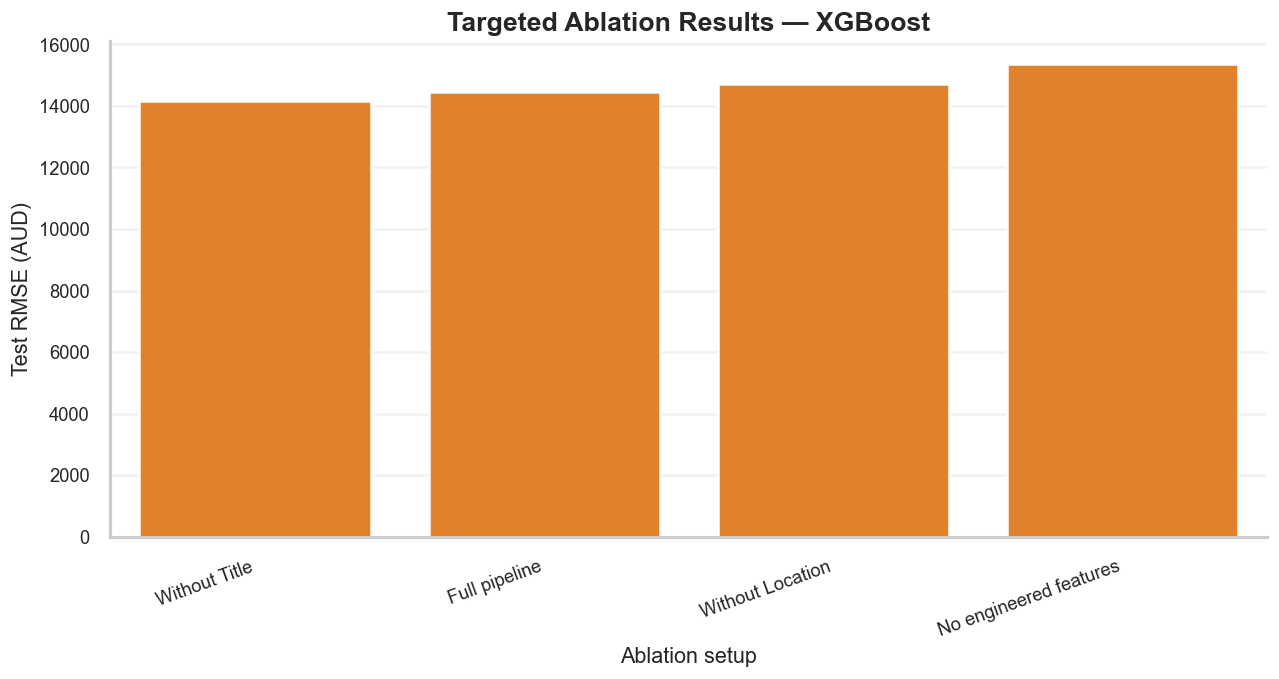

In [24]:
# ============================================================
# Cell 24 — Ablation summary and interpretation
# ============================================================
# Purpose:
# Summarise the ablation experiments relative to the full reference
# pipeline and interpret which modelling choices add the greatest value.

if "ablation_results_df" not in globals() or ablation_results_df.empty:
    raise ValueError("Ablation results are not available. Run Cell 23 first.")

reference_row = ablation_results_df.loc[
    ablation_results_df["ablation_name"] == "Full pipeline"
]

if reference_row.empty:
    raise ValueError("Reference ablation row 'Full pipeline' not found.")

reference_row = reference_row.iloc[0]

ablation_summary_df = ablation_results_df.copy()
ablation_summary_df["Delta_CV_RMSE_log_vs_full"] = (
    ablation_summary_df["CV_RMSE_log_mean"] - reference_row["CV_RMSE_log_mean"]
)
ablation_summary_df["Delta_Test_RMSE_AUD_vs_full"] = (
    ablation_summary_df["Test_RMSE_AUD"] - reference_row["Test_RMSE_AUD"]
)
ablation_summary_df["Delta_Test_MAE_AUD_vs_full"] = (
    ablation_summary_df["Test_MAE_AUD"] - reference_row["Test_MAE_AUD"]
)
ablation_summary_df["Delta_Test_R2_AUD_vs_full"] = (
    ablation_summary_df["Test_R2_AUD"] - reference_row["Test_R2_AUD"]
)

ablation_summary_df = ablation_summary_df.sort_values(
    by="Delta_Test_RMSE_AUD_vs_full",
    ascending=True
).reset_index(drop=True)

display(
    style_table(
        ablation_summary_df.round(4),
        gradient_subset=[
            "Delta_CV_RMSE_log_vs_full",
            "Delta_Test_RMSE_AUD_vs_full",
            "Delta_Test_MAE_AUD_vs_full",
            "Delta_Test_R2_AUD_vs_full"
        ]
    )
)

best_ablation_row = ablation_summary_df.iloc[0]
worst_ablation_row = ablation_summary_df.iloc[-1]

print(
    f"Reference setup: the full pipeline remains the benchmark configuration for comparison "
    f"using the {base_ablation_model_name} model family."
)

print(
    f"Best ablation result: {best_ablation_row['ablation_name']} achieved the strongest "
    f"test-set RMSE among the ablation configurations."
)

print(
    f"Largest performance loss: {worst_ablation_row['ablation_name']} produced the weakest "
    "result relative to the full pipeline, indicating that the removed information was valuable."
)

print(
    "Interpretation: If removing a component worsens both cross-validation and locked "
    "test-set performance, that component is likely contributing meaningful predictive signal "
    "rather than incidental noise."
)

if "Without Title" in ablation_summary_df["ablation_name"].values:
    title_row = ablation_summary_df.loc[
        ablation_summary_df["ablation_name"] == "Without Title"
    ].iloc[0]
    print(
        f"Title ablation note: removing Title changed test RMSE by "
        f"{title_row['Delta_Test_RMSE_AUD_vs_full']:.2f} AUD relative to the full pipeline."
    )

if "No engineered features" in ablation_summary_df["ablation_name"].values:
    eng_row = ablation_summary_df.loc[
        ablation_summary_df["ablation_name"] == "No engineered features"
    ].iloc[0]
    print(
        f"Feature-engineering note: removing engineered features changed test RMSE by "
        f"{eng_row['Delta_Test_RMSE_AUD_vs_full']:.2f} AUD relative to the full pipeline."
    )

# ------------------------------------------------------------
# Ablation comparison plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

plot_ablation = ablation_results_df.sort_values(by="Test_RMSE_AUD", ascending=True).copy()

if SEABORN_OK:
    sns.barplot(
        data=plot_ablation,
        x="ablation_name",
        y="Test_RMSE_AUD",
        color=COLORS["secondary"],
        ax=ax
    )
else:
    ax.bar(
        plot_ablation["ablation_name"],
        plot_ablation["Test_RMSE_AUD"],
        color=COLORS["secondary"]
    )

ax.set_title(f"Targeted Ablation Results — {base_ablation_model_name}")
ax.set_xlabel("Ablation setup")
ax.set_ylabel("Test RMSE (AUD)")
ax.ticklabel_format(style="plain", axis="y")
format_axis(ax, rotate_xticks=20)

show_and_save(fig, "figure_13_ablation_test_rmse.png")

In [25]:
# ============================================================
# Cell 25 — Export final outputs
# ============================================================
# Purpose:
# Export the final comparison tables, diagnostics, interpretability,
# ablation outputs, and reproducibility summaries for use in the
# report, appendix, and GitHub repository.

# Ensure output directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Core tabular outputs
# ------------------------------------------------------------
export_objects = {
    "final_model_comparison.csv": final_comparison_df,
    "test_set_results.csv": test_results_df,
    "cv_summary_results.csv": cv_summary_df,
    "cv_fold_results.csv": cv_results_df,
    "best_model_diagnostics.csv": diagnostic_df,
    "error_by_price_band.csv": band_summary,
    "permutation_importance_top20.csv": top_importance_df,
    "ablation_results.csv": ablation_results_df,
    "ablation_summary.csv": ablation_summary_df,
}

# Optional outputs
if "tuning_df" in globals() and isinstance(tuning_df, pd.DataFrame) and not tuning_df.empty:
    export_objects["tuning_summary.csv"] = tuning_df

if "runtime_df" in globals() and isinstance(runtime_df, pd.DataFrame) and not runtime_df.empty:
    export_objects["cv_runtime_summary.csv"] = runtime_df

if "cv_rank_df" in globals() and isinstance(cv_rank_df, pd.DataFrame) and not cv_rank_df.empty:
    export_objects["cv_ranked_models.csv"] = cv_rank_df

saved_files = []
for filename, obj in export_objects.items():
    if isinstance(obj, pd.DataFrame) and not obj.empty:
        obj.to_csv(OUTPUT_DIR / filename, index=False)
        saved_files.append(filename)

# ------------------------------------------------------------
# Optional brand-level export
# ------------------------------------------------------------
brand_candidates = ["Brand", "Make", "Manufacturer", "brand", "make"]
brand_col_export = next((c for c in brand_candidates if c in X_test.columns), None)

brand_summary_export = None
if brand_col_export is not None:
    err_brand_export = pd.DataFrame({
        brand_col_export: X_test[brand_col_export].astype(str).fillna("Unknown").values,
        "absolute_error": diagnostic_df["absolute_error"].values,
        "actual_price": diagnostic_df["actual_price"].values
    })

    brand_summary_export = (
        err_brand_export.groupby(brand_col_export)
        .agg(
            n=("absolute_error", "size"),
            MAE_AUD=("absolute_error", "mean"),
            median_price=("actual_price", "median")
        )
        .reset_index()
    )

    brand_summary_export = brand_summary_export[brand_summary_export["n"] >= 30].copy()

    if not brand_summary_export.empty:
        brand_summary_export.to_csv(OUTPUT_DIR / "error_by_brand.csv", index=False)
        saved_files.append("error_by_brand.csv")

# ------------------------------------------------------------
# Project-level JSON summary
# ------------------------------------------------------------
project_summary = {
    "best_model": best_model_name,
    "best_test_rmse_aud": round(float(best_row["RMSE_AUD"]), 4),
    "best_test_mae_aud": round(float(best_row["MAE_AUD"]), 4),
    "best_test_r2_aud": round(float(best_row["R2_AUD"]), 4),
    "best_cv_rmse_log": round(float(best_row["CV_RMSE_log_mean"]), 4),
    "best_cv_mae_log": round(float(best_row["CV_MAE_log_mean"]), 4),
    "best_cv_r2_log": round(float(best_row["CV_R2_log_mean"]), 4),
    "n_models_evaluated": int(len(test_results_df)),
    "cv_folds": int(CV_FOLDS),
    "test_size": float(TEST_SIZE),
    "random_state": int(RANDOM_STATE),
}

with open(OUTPUT_DIR / "project_summary.json", "w", encoding="utf-8") as f:
    json.dump(project_summary, f, indent=2)

saved_files.append("project_summary.json")

# ------------------------------------------------------------
# Reproducibility snapshot export
# ------------------------------------------------------------
if "snapshot" in globals() and isinstance(snapshot, dict):
    with open(OUTPUT_DIR / "reproducibility_snapshot.json", "w", encoding="utf-8") as f:
        json.dump(snapshot, f, indent=2)
    saved_files.append("reproducibility_snapshot.json")

# ------------------------------------------------------------
# Export summary
# ------------------------------------------------------------
export_summary = pd.DataFrame({
    "Output file": saved_files,
    "Saved": [True] * len(saved_files)
}).sort_values(by="Output file").reset_index(drop=True)

display(style_table(export_summary))
print(f"All final outputs saved to: {OUTPUT_DIR}")

,Output file,Saved
0,ablation_results.csv,True
1,ablation_summary.csv,True
2,best_model_diagnostics.csv,True
3,cv_fold_results.csv,True
4,cv_ranked_models.csv,True
5,cv_runtime_summary.csv,True
6,cv_summary_results.csv,True
7,error_by_brand.csv,True
8,error_by_price_band.csv,True
9,final_model_comparison.csv,True


All final outputs saved to: c:\Users\girid\OneDrive\Desktop\Mahesh Data Science Project\outputs
